In [80]:
import sys
print(sys.executable)

import pandas as pd
print(pd.__version__)

c:\Users\sujal\OneDrive\Desktop\AI-RootCause-Investigator\venv\Scripts\python.exe
3.0.5


In [81]:
import pandas as pd

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [82]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [83]:
orders.shape

(99441, 8)

In [84]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["date"]=orders["order_purchase_timestamp"].dt.date
daily_orders=orders.groupby("date").size()
daily_orders.head(10)

date
2016-09-04     1
2016-09-05     1
2016-09-13     1
2016-09-15     1
2016-10-02     1
2016-10-03     8
2016-10-04    63
2016-10-05    47
2016-10-06    51
2016-10-07    46
dtype: int64

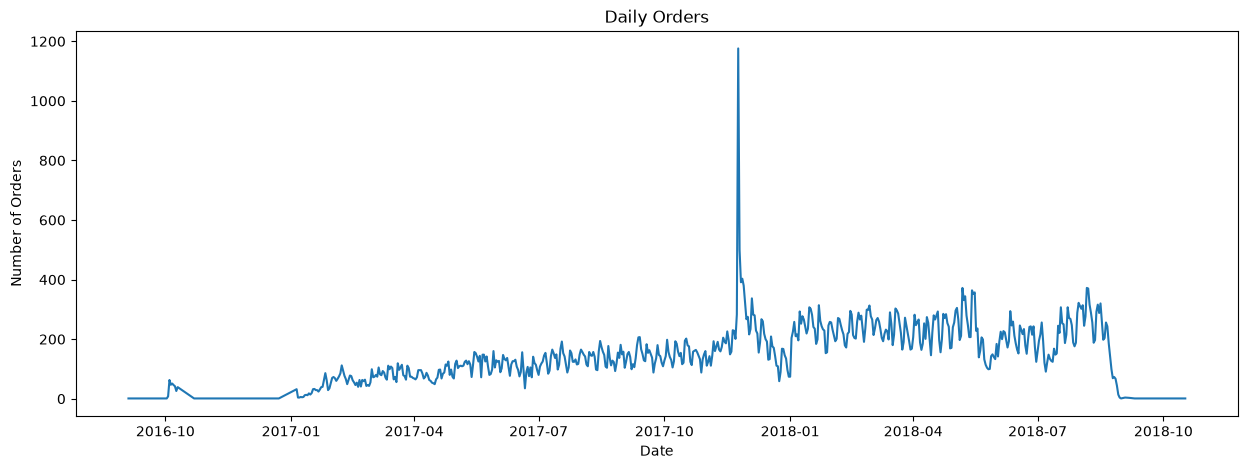

In [85]:
import matplotlib.pyplot as plt
daily_orders.plot(figsize=(15, 5))
plt.title("Daily Orders")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.show()

In [86]:
daily_orders = daily_orders.asfreq("D", fill_value=0)
daily_orders.head(15)

date
2016-09-04    1
2016-09-05    1
2016-09-06    0
2016-09-07    0
2016-09-08    0
2016-09-09    0
2016-09-10    0
2016-09-11    0
2016-09-12    0
2016-09-13    1
2016-09-14    0
2016-09-15    1
2016-09-16    0
2016-09-17    0
2016-09-18    0
Freq: D, dtype: int64

In [87]:
print(daily_orders.tail(15))
print("Start date:", daily_orders.index.min())
print("End date:", daily_orders.index.max())
print("Total days:", len(daily_orders))
print(daily_orders.describe())

date
2018-10-03    1
2018-10-04    0
2018-10-05    0
2018-10-06    0
2018-10-07    0
2018-10-08    0
2018-10-09    0
2018-10-10    0
2018-10-11    0
2018-10-12    0
2018-10-13    0
2018-10-14    0
2018-10-15    0
2018-10-16    1
2018-10-17    1
Freq: D, dtype: int64
Start date: 2016-09-04 00:00:00
End date: 2018-10-17 00:00:00
Total days: 774
count     774.000000
mean      128.476744
std       104.498687
min         0.000000
25%        42.250000
50%       124.000000
75%       198.000000
max      1176.000000
dtype: float64


In [88]:
cutoff_date= "2018-07-01"
train= daily_orders[daily_orders.index < cutoff_date]
test= daily_orders[daily_orders.index >= cutoff_date]
print("Training data:",train.index.min(),"to", train.index.max())
print("Testing data:",test.index.min(),"to", test.index.max())
print("Train days:",len(train))
print("Test days:",len(test))

Training data: 2016-09-04 00:00:00 to 2018-06-30 00:00:00
Testing data: 2018-07-01 00:00:00 to 2018-10-17 00:00:00
Train days: 665
Test days: 109


In [89]:
last_30_days = train.tail(30)
prediction = last_30_days.mean()
print("Expected orders per day:", prediction)

Expected orders per day: 205.56666666666666


In [90]:
july_actual = test[test.index < "2018-08-01"]
print("Actual July average:", july_actual.mean())
print("Predicted July average:", prediction)

Actual July average: 202.96774193548387
Predicted July average: 205.56666666666666


In [91]:
difference = july_actual.mean() - prediction
percentage_error = (difference / prediction) * 100
print("Difference:", difference)
print("Percentage difference:", percentage_error)

Difference: -2.598924731182791
Percentage difference: -1.2642734220120597


In [92]:
daily_prediction = train.tail(30).mean()
predicted_july = pd.Series(
    daily_prediction,
    index=july_actual.index
)
print(predicted_july.head())

date
2018-07-01    205.566667
2018-07-02    205.566667
2018-07-03    205.566667
2018-07-04    205.566667
2018-07-05    205.566667
Freq: D, dtype: float64


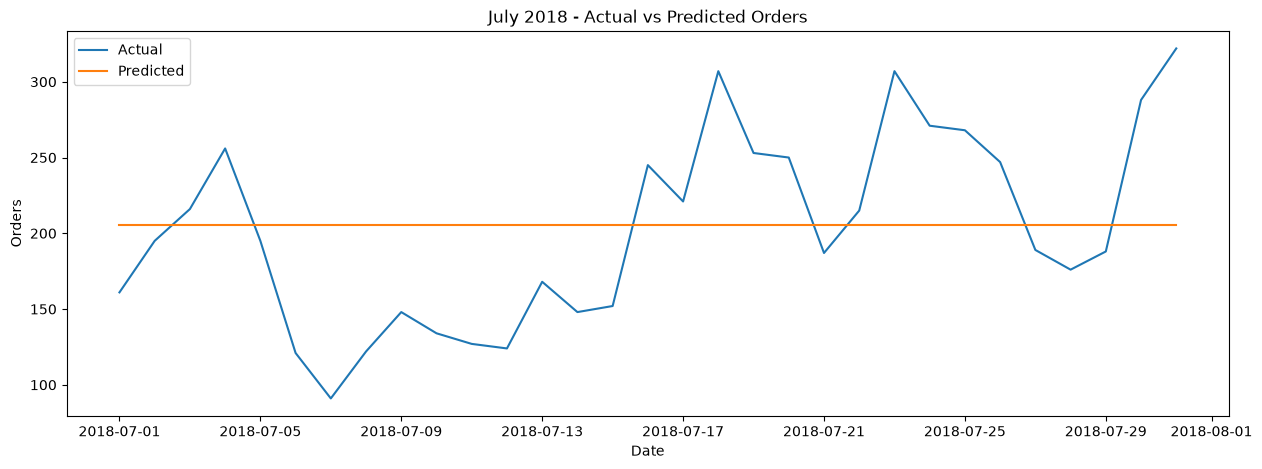

In [93]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(july_actual.index, july_actual.values, label="Actual")
plt.plot(predicted_july.index, predicted_july.values, label="Predicted")
plt.title("July 2018 - Actual vs Predicted Orders")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.legend()
plt.show()

In [94]:
train_df = train.to_frame(name="orders")
train_df["day_of_week"] = train_df.index.dayofweek
weekday_average = train_df.groupby("day_of_week")["orders"].mean()
print(weekday_average)

day_of_week
0    147.568421
1    145.505263
2    141.831579
3    135.557895
4    131.231579
5    100.884211
6    109.178947
Name: orders, dtype: float64


In [95]:
predicted_july = july_actual.index.to_series().map(
    lambda date: weekday_average[date.dayofweek])
predicted_july.index = july_actual.index
print(predicted_july.head(10))

date
2018-07-01    109.178947
2018-07-02    147.568421
2018-07-03    145.505263
2018-07-04    141.831579
2018-07-05    135.557895
2018-07-06    131.231579
2018-07-07    100.884211
2018-07-08    109.178947
2018-07-09    147.568421
2018-07-10    145.505263
Freq: D, Name: date, dtype: float64


In [96]:
comparison = pd.DataFrame({
    "Actual": july_actual,
    "Predicted": predicted_july
})

comparison.head(10)

,Actual,Predicted
date,,
2018-07-01,161,109.178947
2018-07-02,195,147.568421
2018-07-03,216,145.505263
2018-07-04,256,141.831579
2018-07-05,195,135.557895
2018-07-06,121,131.231579
2018-07-07,91,100.884211
2018-07-08,122,109.178947
2018-07-09,148,147.568421


In [97]:
ml_data = daily_orders.to_frame(name="orders")
ml_data["lag_1"] = ml_data["orders"].shift(1)
ml_data["lag_7"] = ml_data["orders"].shift(7)
ml_data["rolling_7"] = ml_data["orders"].shift(1).rolling(7).mean()
ml_data.head(15)

,orders,lag_1,lag_7,rolling_7
date,,,,
2016-09-04,1,NaN,NaN,NaN
2016-09-05,1,1.0,NaN,NaN
2016-09-06,0,1.0,NaN,NaN
2016-09-07,0,0.0,NaN,NaN
2016-09-08,0,0.0,NaN,NaN
2016-09-09,0,0.0,NaN,NaN
2016-09-10,0,0.0,NaN,NaN
2016-09-11,0,0.0,1.0,0.285714
2016-09-12,0,0.0,1.0,0.142857


In [98]:
ml_data["day_of_week"] = ml_data.index.dayofweek

ml_data.head(15)

,orders,lag_1,lag_7,rolling_7,day_of_week
date,,,,,
2016-09-04,1,NaN,NaN,NaN,6
2016-09-05,1,1.0,NaN,NaN,0
2016-09-06,0,1.0,NaN,NaN,1
2016-09-07,0,0.0,NaN,NaN,2
2016-09-08,0,0.0,NaN,NaN,3
2016-09-09,0,0.0,NaN,NaN,4
2016-09-10,0,0.0,NaN,NaN,5
2016-09-11,0,0.0,1.0,0.285714,6
2016-09-12,0,0.0,1.0,0.142857,0


In [99]:
ml_data = ml_data.dropna()

print(ml_data.shape)
ml_data.head()

(767, 5)


,orders,lag_1,lag_7,rolling_7,day_of_week
date,,,,,
2016-09-11,0,0.0,1.0,0.285714,6
2016-09-12,0,0.0,1.0,0.142857,0
2016-09-13,1,0.0,0.0,0.000000,1
2016-09-14,0,1.0,0.0,0.142857,2
2016-09-15,1,0.0,0.0,0.142857,3


In [100]:
train_ml = ml_data[ml_data.index < "2018-07-01"]
test_ml = ml_data[ml_data.index >= "2018-07-01"]

print("Train:", train_ml.shape)
print("Test:", test_ml.shape)

Train: (658, 5)
Test: (109, 5)


In [101]:
features = ["lag_1", "lag_7", "rolling_7", "day_of_week"]

X_train = train_ml[features]
y_train = train_ml["orders"]

X_test = test_ml[features]
y_test = test_ml["orders"]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(658, 4)
(658,)
(109, 4)
(109,)


In [102]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(predictions[:10])

[141.115 227.98  221.5   218.045 258.035 178.535 132.105 123.545 177.725
 159.305]


In [103]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.head(10)

,Actual,Predicted
date,,
2018-07-01,161,141.115
2018-07-02,195,227.980
2018-07-03,216,221.500
2018-07-04,256,218.045
2018-07-05,195,258.035
2018-07-06,121,178.535
2018-07-07,91,132.105
2018-07-08,122,123.545
2018-07-09,148,177.725


In [104]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

MAE: 24.034215858965418
RMSE: 52.33733574629822


4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  

In [105]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R²:", r2)

R²: 0.8171718253291337


In [106]:
# Calculate prediction error
results["error"] = results["Actual"] - results["Predicted"]

# Calculate absolute error
results["absolute_error"] = results["error"].abs()

# Show the 10 dates where the model made the biggest mistakes
top_errors = results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

print(top_errors)

            Actual  Predicted    error  absolute_error
date                                                  
2018-07-19     253    673.710 -420.710         420.710
2018-08-28      44    149.580 -105.580         105.580
2018-08-27      67    163.705  -96.705          96.705
2018-07-18     307    211.915   95.085          95.085
2018-08-24      99    192.390  -93.390          93.390
2018-07-16     245    166.775   78.225          78.225
2018-08-06     372    296.630   75.370          75.370
2018-08-05     276    203.280   72.720          72.720
2018-08-29      14     83.590  -69.590          69.590
2018-08-23     144    209.605  -65.605          65.605


In [107]:
# Date we want to investigate
investigation_date = "2018-07-19"

# Get all orders from that date
day_orders = orders[
    orders["order_purchase_timestamp"].dt.date
    == pd.to_datetime(investigation_date).date()
]

# Basic information
print("Date:", investigation_date)
print("Total orders:", len(day_orders))

# Order status breakdown
print("\nOrder status:")
print(day_orders["order_status"].value_counts())
print("July 19 features:")
print(ml_data.loc["2018-07-19"])

Date: 2018-07-19
Total orders: 253

Order status:
order_status
delivered    249
shipped        4
Name: count, dtype: int64
July 19 features:
orders         253.0
lag_1          307.0
lag_7          124.0
rolling_7      195.0
day_of_week      3.0
Name: 2018-07-19 00:00:00, dtype: float64


In [108]:
# Look at the days around the anomaly
check_period = results.loc["2018-07-12":"2018-07-25"]
print(check_period[["Actual", "Predicted", "error"]])
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)
print(feature_importance)

            Actual  Predicted    error
date                                  
2018-07-12     124    124.145   -0.145
2018-07-13     168    137.100   30.900
2018-07-14     148    125.635   22.365
2018-07-15     152    160.460   -8.460
2018-07-16     245    166.775   78.225
2018-07-17     221    215.475    5.525
2018-07-18     307    211.915   95.085
2018-07-19     253    673.710 -420.710
2018-07-20     250    188.660   61.340
2018-07-21     187    188.345   -1.345
2018-07-22     215    184.400   30.600
2018-07-23     307    272.825   34.175
2018-07-24     271    282.745  -11.745
2018-07-25     268    264.045    3.955
lag_1          0.509378
rolling_7      0.339185
lag_7          0.128942
day_of_week    0.022495
dtype: float64


In [109]:
results["percentage_error"] = (
    results["error"].abs() / results["Predicted"]
) * 100

results.sort_values(
    "percentage_error",
    ascending=False
).head(15)

,Actual,Predicted,error,absolute_error,percentage_error
date,,,,,
2018-10-01,1,0.000000,1.000000,1.000000,inf
2018-10-03,1,0.000000,1.000000,1.000000,inf
2018-09-10,1,0.000000,1.000000,1.000000,inf
2018-09-17,1,0.000000,1.000000,1.000000,inf
2018-09-29,1,0.002687,0.997313,0.997313,3.711805e+04
2018-09-25,1,0.007698,0.992302,0.992302,1.289012e+04
2018-09-06,3,0.150248,2.849752,2.849752,1.896699e+03
2018-10-16,1,0.076743,0.923257,0.923257,1.203047e+03
2018-09-20,1,0.150248,0.849752,0.849752,5.655662e+02


In [110]:
# Ignore very low predicted-volume days
# because percentage error becomes misleading near zero

meaningful_results = results[
    (results["Predicted"] >= 50) &
    (results.index < "2018-09-01")
].copy()

# Calculate percentage difference safely
meaningful_results["percentage_error"] = (
    meaningful_results["error"].abs()
    / meaningful_results["Predicted"]
) * 100

# Show the biggest deviations
top_anomalies = meaningful_results.sort_values(
    "percentage_error",
    ascending=False
).head(15)

print(top_anomalies[
    ["Actual", "Predicted", "error", "percentage_error"]
])

            Actual  Predicted    error  percentage_error
date                                                    
2018-08-30       4     54.575  -50.575         92.670637
2018-08-29      14     83.590  -69.590         83.251585
2018-08-28      44    149.580 -105.580         70.584303
2018-07-19     253    673.710 -420.710         62.446750
2018-08-27      67    163.705  -96.705         59.072722
2018-08-24      99    192.390  -93.390         48.542024
2018-07-16     245    166.775   78.225         46.904512
2018-08-25      69    128.525  -59.525         46.313947
2018-07-18     307    211.915   95.085         44.869405
2018-08-26      73    124.545  -51.545         41.386647
2018-08-05     276    203.280   72.720         35.773318
2018-07-20     250    188.660   61.340         32.513516
2018-07-06     121    178.535  -57.535         32.226174
2018-08-23     144    209.605  -65.605         31.299349
2018-07-07      91    132.105  -41.105         31.115401


In [111]:
period = daily_orders.loc[
    "2018-08-23":"2018-09-02"
]

print(period)

date
2018-08-23    144
2018-08-24     99
2018-08-25     69
2018-08-26     73
2018-08-27     67
2018-08-28     44
2018-08-29     14
2018-08-30      4
2018-08-31      1
2018-09-01      0
2018-09-02      0
Freq: D, dtype: int64


In [112]:
investigation_date = "2018-08-30"

day_orders = orders[
    orders["order_purchase_timestamp"].dt.date
    == pd.to_datetime(investigation_date).date()
]

print("Total orders:", len(day_orders))
print("\nOrder status:")
print(day_orders["order_status"].value_counts())

Total orders: 4

Order status:
order_status
canceled    4
Name: count, dtype: int64


In [113]:
print(ml_data.loc["2018-08-30"])

orders           4.000000
lag_1           14.000000
lag_7          144.000000
rolling_7       72.857143
day_of_week      3.000000
Name: 2018-08-30 00:00:00, dtype: float64


In [114]:
# Select the period we are investigating
investigation_period = orders[
    (orders["order_purchase_timestamp"] >= "2018-08-23") &
    (orders["order_purchase_timestamp"] < "2018-09-03")
].copy()

# Count orders by date and status
status_by_day = pd.crosstab(
    investigation_period["order_purchase_timestamp"].dt.date,
    investigation_period["order_status"]
)

print(status_by_day)

order_status              canceled  delivered  shipped
order_purchase_timestamp                              
2018-08-23                       2        142        0
2018-08-24                       2         96        1
2018-08-25                       0         69        0
2018-08-26                       0         73        0
2018-08-27                       1         66        0
2018-08-28                       5         39        0
2018-08-29                       3         11        0
2018-08-30                       4          0        0
2018-08-31                       1          0        0


In [115]:
investigation_period = orders[
    (orders["order_purchase_timestamp"] >= "2018-08-23") &
    (orders["order_purchase_timestamp"] < "2018-09-03")
].copy()

status_by_day = pd.crosstab(
    investigation_period["order_purchase_timestamp"].dt.date,
    investigation_period["order_status"]
)

print(status_by_day)
investigation_period["hour"] = (
    investigation_period["order_purchase_timestamp"].dt.hour
)

hourly_orders = investigation_period.groupby("hour").size()

print(hourly_orders)

order_status              canceled  delivered  shipped
order_purchase_timestamp                              
2018-08-23                       2        142        0
2018-08-24                       2         96        1
2018-08-25                       0         69        0
2018-08-26                       0         73        0
2018-08-27                       1         66        0
2018-08-28                       5         39        0
2018-08-29                       3         11        0
2018-08-30                       4          0        0
2018-08-31                       1          0        0
hour
0     16
1      4
2      2
3      1
4      3
6      2
7      8
8     17
9     30
10    33
11    47
12    29
13    37
14    35
15    28
16    30
17    37
18    24
19    37
20    29
21    32
22    21
23    13
dtype: int64


In [116]:
# Get all cancelled orders from the investigation period
cancelled_orders = investigation_period[
    investigation_period["order_status"] == "canceled"
].copy()

# Show important information
print("Total cancelled orders:", len(cancelled_orders))

print("\nCancelled orders:")
print(
    cancelled_orders[
        [
            "order_id",
            "customer_id",
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date"
        ]
    ].to_string(index=False)
)

Total cancelled orders: 18

Cancelled orders:
                        order_id                      customer_id order_purchase_timestamp   order_approved_at order_delivered_carrier_date order_delivered_customer_date
00b1cb0320190ca0daa2c88b35206009 3532ba38a3fd242259a514ac2b6ae6b6      2018-08-28 15:26:39                 NaN                          NaN                           NaN
8d4c637f1accf7a88a4555f02741e606 b1dd715db389a2077f43174e7a675d07      2018-08-29 16:27:49                 NaN                          NaN                           NaN
85e05c3c9aa9834518f35d4f286014be 1d07a80a15700b40cb15ff5870ee8b48      2018-08-28 08:18:22                 NaN                          NaN                           NaN
0a472c47d928bf4cd8b6a7a30345eeb7 8762d94c493b70216cd453ea2320234e      2018-08-30 10:14:00                 NaN                          NaN                           NaN
15ec3d48383c58c0dc96cd66f8884630 fc768a2275c44d9383cc6926adac469d      2018-08-23 15:17:19              

In [117]:
# Daily order and cancellation analysis

daily_status = pd.crosstab(
    investigation_period["order_purchase_timestamp"].dt.date,
    investigation_period["order_status"]
)

daily_status["total_orders"] = daily_status.sum(axis=1)

daily_status["cancellation_rate"] = (
    daily_status.get("canceled", 0)
    / daily_status["total_orders"]
) * 100

print(daily_status)

order_status              canceled  delivered  shipped  total_orders  \
order_purchase_timestamp                                               
2018-08-23                       2        142        0           144   
2018-08-24                       2         96        1            99   
2018-08-25                       0         69        0            69   
2018-08-26                       0         73        0            73   
2018-08-27                       1         66        0            67   
2018-08-28                       5         39        0            44   
2018-08-29                       3         11        0            14   
2018-08-30                       4          0        0             4   
2018-08-31                       1          0        0             1   

order_status              cancellation_rate  
order_purchase_timestamp                     
2018-08-23                         1.388889  
2018-08-24                         2.020202  
2018-08-25             

In [118]:
# Check how many orders exist by month

monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

print(monthly_orders)

order_purchase_timestamp
2016-09-30       4
2016-10-31     324
2016-11-30       0
2016-12-31       1
2017-01-31     800
2017-02-28    1780
2017-03-31    2682
2017-04-30    2404
2017-05-31    3700
2017-06-30    3245
2017-07-31    4026
2017-08-31    4331
2017-09-30    4285
2017-10-31    4631
2017-11-30    7544
2017-12-31    5673
2018-01-31    7269
2018-02-28    6728
2018-03-31    7211
2018-04-30    6939
2018-05-31    6873
2018-06-30    6167
2018-07-31    6292
2018-08-31    6512
2018-09-30      16
2018-10-31       4
Freq: ME, dtype: int64


In [119]:
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [120]:
# Only investigate the reliable period
reliable_results = results[
    (results.index >= "2017-01-01") &
    (results.index <= "2018-08-20") &
    (results["Predicted"] >= 50)
].copy()

# Percentage deviation
reliable_results["percentage_error"] = (
    reliable_results["error"].abs()
    / reliable_results["Predicted"]
) * 100

# Top 15 candidates
top_clean_anomalies = reliable_results.sort_values(
    "percentage_error",
    ascending=False
).head(15)

print(
    top_clean_anomalies[
        ["Actual", "Predicted", "error", "percentage_error"]
    ]
)

            Actual  Predicted    error  percentage_error
date                                                    
2018-07-19     253    673.710 -420.710         62.446750
2018-07-16     245    166.775   78.225         46.904512
2018-07-18     307    211.915   95.085         44.869405
2018-08-05     276    203.280   72.720         35.773318
2018-07-20     250    188.660   61.340         32.513516
2018-07-06     121    178.535  -57.535         32.226174
2018-07-07      91    132.105  -41.105         31.115401
2018-08-06     372    296.630   75.370         25.408758
2018-07-05     195    258.035  -63.035         24.428857
2018-08-16     320    258.530   61.470         23.776738
2018-07-13     168    137.100   30.900         22.538293
2018-07-31     322    264.385   57.615         21.792084
2018-08-11     188    235.900  -47.900         20.305214
2018-08-20     256    313.170  -57.170         18.255261
2018-07-14     148    125.635   22.365         17.801568


In [121]:
investigation_date = "2018-07-18"

day_orders = orders[
    orders["order_purchase_timestamp"].dt.date
    == pd.to_datetime(investigation_date).date()
].copy()

print("Date:", investigation_date)
print("Total orders:", len(day_orders))

print("\nOrder status:")
print(day_orders["order_status"].value_counts())

print("\nOrder IDs:")
print(day_orders["order_id"].head(10).to_list())

Date: 2018-07-18
Total orders: 307

Order status:
order_status
delivered      302
shipped          2
unavailable      1
canceled         1
invoiced         1
Name: count, dtype: int64

Order IDs:
['89165e6d4c28047da0adf13ac8b3e1b3', 'ad7ddb009f1bcd6c40cb1106471c292c', 'a11ebb9e9f1a018eea99fe7105f2d897', '90855e99e15fa22aff68cdb4323b27c9', '84cf671bc3869df812c782309ef46a8d', 'bf2910ffd07baa17d7d2ce5a170da758', '2fe72d522af94b1264d79a8e6e41f933', '784389cee609eccd4f055e1eb8544285', 'e0392865844b1934818565a516cf8bdb', '6b6634917b74d4db4d32cf09754c061d']


In [122]:
# Load order items and products

order_items = pd.read_csv(
    "../data/raw/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "../data/raw/olist_products_dataset.csv"
)

print("Order items:", order_items.shape)
print("Products:", products.shape)

print("\nOrder items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Order items: (112650, 7)
Products: (32951, 9)

Order items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [123]:
# Get product information for July 18 orders

july18_items = order_items[
    order_items["order_id"].isin(day_orders["order_id"])
].copy()

# Join product information
july18_products = july18_items.merge(
    products[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

print("Total items:", len(july18_products))

print("\nTop product categories:")
print(
    july18_products["product_category_name"]
    .value_counts()
    .head(15)
)

Total items: 340

Top product categories:
product_category_name
cama_mesa_banho                      43
beleza_saude                         42
informatica_acessorios               21
relogios_presentes                   20
automotivo                           20
esporte_lazer                        19
moveis_decoracao                     19
utilidades_domesticas                18
bebes                                10
moveis_escritorio                    10
telefonia                             9
papelaria                             9
construcao_ferramentas_construcao     8
pet_shop                              8
perfumaria                            7
Name: count, dtype: int64


In [124]:
# Get product categories for ALL orders in July 1-17
# This will be our baseline period

baseline_orders = orders[
    (orders["order_purchase_timestamp"] >= "2018-07-01") &
    (orders["order_purchase_timestamp"] < "2018-07-18")
].copy()

baseline_items = order_items[
    order_items["order_id"].isin(baseline_orders["order_id"])
].copy()

baseline_products = baseline_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Category distribution during baseline
baseline_category_counts = (
    baseline_products["product_category_name"]
    .value_counts()
)

baseline_category_share = (
    baseline_category_counts
    / baseline_category_counts.sum()
    * 100
)

print("Baseline category share:")
print(baseline_category_share.head(15))

Baseline category share:
product_category_name
beleza_saude              13.484946
cama_mesa_banho            8.648302
relogios_presentes         8.424087
utilidades_domesticas      7.783472
esporte_lazer              6.694427
informatica_acessorios     5.989750
moveis_decoracao           5.381166
automotivo                 4.804612
bebes                      2.882767
ferramentas_jardim         2.754644
telefonia                  2.690583
perfumaria                 2.658552
papelaria                  2.370275
brinquedos                 2.338245
eletronicos                2.306214
Name: count, dtype: float64


In [125]:
# July 18 category distribution

july18_category_counts = (
    july18_products["product_category_name"]
    .value_counts()
)

july18_category_share = (
    july18_category_counts
    / july18_category_counts.sum()
    * 100
)

print("July 18 category share:")
print(july18_category_share.head(15))

July 18 category share:
product_category_name
cama_mesa_banho                      12.721893
beleza_saude                         12.426036
informatica_acessorios                6.213018
relogios_presentes                    5.917160
automotivo                            5.917160
esporte_lazer                         5.621302
moveis_decoracao                      5.621302
utilidades_domesticas                 5.325444
bebes                                 2.958580
moveis_escritorio                     2.958580
telefonia                             2.662722
papelaria                             2.662722
construcao_ferramentas_construcao     2.366864
pet_shop                              2.366864
perfumaria                            2.071006
Name: count, dtype: float64


In [126]:
# Compare cama_mesa_banho category across individual days

baseline_items["date"] = (
    baseline_orders["order_purchase_timestamp"]
    .dt.date
)

baseline_category_daily = (
    baseline_products
    .groupby(["date", "product_category_name"])
    .size()
    .unstack(fill_value=0)
)

# Get cama_mesa_banho daily counts
cama_daily = baseline_category_daily[
    "cama_mesa_banho"
]

print("Cama/Mesa/Banho - July 1 to July 17:")
print(cama_daily)

print("\nStatistics:")
print(cama_daily.describe())

KeyError: 'date'

In [ ]:
# Create date directly inside baseline_products

baseline_products = baseline_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

baseline_products["date"] = (
    baseline_products["order_id"]
    .map(
        baseline_orders.set_index("order_id")["order_purchase_timestamp"]
    )
    .dt.date
)

# Daily category counts
baseline_category_daily = (
    baseline_products
    .groupby(["date", "product_category_name"])
    .size()
    .unstack(fill_value=0)
)

# Check cama_mesa_banho
if "cama_mesa_banho" in baseline_category_daily.columns:
    cama_daily = baseline_category_daily["cama_mesa_banho"]

    print("Cama/Mesa/Banho - July 1 to July 17:")
    print(cama_daily)

    print("\nStatistics:")
    print(cama_daily.describe())
else:
    print("cama_mesa_banho category not found")

Cama/Mesa/Banho - July 1 to July 17:
date
2018-07-01    19
2018-07-02    19
2018-07-03    25
2018-07-04    37
2018-07-05    21
2018-07-06     7
2018-07-07    10
2018-07-08     9
2018-07-09    11
2018-07-10     9
2018-07-11     9
2018-07-12     7
2018-07-13     8
2018-07-14    19
2018-07-15    17
2018-07-16    19
2018-07-17    24
Name: cama_mesa_banho, dtype: int64

Statistics:
count    17.000000
mean     15.882353
std       8.222548
min       7.000000
25%       9.000000
50%      17.000000
75%      19.000000
max      37.000000
Name: cama_mesa_banho, dtype: float64


In [ ]:
# Products sold in cama_mesa_banho on July 18

cama_july18 = july18_products[
    july18_products["product_category_name"] == "cama_mesa_banho"
].copy()

product_counts = (
    cama_july18["product_id"]
    .value_counts()
    .head(15)
)

print("Top products in cama_mesa_banho on July 18:")
print(product_counts)

Top products in cama_mesa_banho on July 18:
product_id
049ac5dce8536884a652ce73c58022ab    4
588ec31c89dea5de5dc87e15790df3f4    3
430315bedd89f81ceec11ba8cc51ebe1    2
0152f69b6cf919bcdaf117aa8c43e5a2    2
950ea5e8d99762513bc4841fee9e7225    2
3beef4346c92eb0b4ad0b7d025dfe15b    2
7340a3839a1de1e99d149b8cf052a2ec    1
7d0b7e7fe3e96e047cacafa33a808bd7    1
3e5201fe0d1ba474d9b90152c83c706c    1
015e04445dedbd5da301ef29cbb03f83    1
630e57ced9d2d899f556e0664be676ab    1
0874407d58fad5ce1eecc2f372fc8dbd    1
703d742887bb9267f89b675608ba7aa0    1
84f456958365164420cfc80fbe4c7fab    1
9712e67c33f564648b46afc6505db72a    1
Name: count, dtype: int64


In [ ]:
# Seller distribution for cama_mesa_banho on July 18

seller_counts = (
    cama_july18["seller_id"]
    .value_counts()
)

print("Number of sellers:", seller_counts.nunique())
print("\nTop sellers:")
print(seller_counts.head(15))

print("\nTotal unique sellers:")
print(seller_counts.size)

Number of sellers: 5

Top sellers:
seller_id
da8622b14eb17ae2831f4ac5b9dab84a    6
4a3ca9315b744ce9f8e9374361493884    5
17ca9b9e9b9ef8fdb529001b49ebb50f    4
709e16e2b25c7474d980076c6bfc4806    4
8160255418d5aaa7dbdc9f4c64ebda44    2
640e21a7d01df7614a3b4923e990d40c    2
7ad32824caee82087b3e2e5f33b1bf32    2
c33847515fa6305ce6feb1e818569f13    2
d2374cbcbb3ca4ab1086534108cc3ab7    2
b29d3380981c51df13fc6fbe87e1763d    2
951e8cef368f09bb3f3d03c00ca4702c    1
dc4a0fc896dc34b0d5bfec8438291c80    1
4e17c65a516f69d023a2ae78b84f28d6    1
a3e9a2c700480d9bb01fba070ba80a0e    1
c53bcd3be457a342a97e39e5a9f0be22    1
Name: count, dtype: int64

Total unique sellers:
22


In [ ]:
# Customer behavior on July 18

unique_customers = day_orders["customer_id"].nunique()

orders_per_customer = (
    day_orders["customer_id"]
    .value_counts()
)

print("Total orders:", len(day_orders))
print("Unique customers:", unique_customers)

print("\nOrders per customer:")
print(orders_per_customer.value_counts().sort_index())

print("\nTop customers by number of orders:")
print(orders_per_customer.head(10))

Total orders: 307
Unique customers: 307

Orders per customer:
count
1    307
Name: count, dtype: int64

Top customers by number of orders:
customer_id
4924a47e8cd5630b3564e26fac55c5ec    1
26495cdb066f046945177209f10b67fb    1
10ee14e89676c9f43e64a67cae62823b    1
b8f2034a26d0832f43daa3a588a9131e    1
72a4d28238f6eeded6dbeba88988cd6f    1
2441a257e681c06ff2101ed765647ada    1
5dce0d6d2ad974afb75df4b6ae8e4ac8    1
97ad0d51c3ad245df8f37e747bbcb423    1
9146a82ef0aef149115d9365555b4343    1
1ac1963cfcf8bda4b3b64300c5b11b16    1
Name: count, dtype: int64


In [ ]:
# Price comparison: July 18 vs July 1-17

july18_price = july18_items["price"].describe()
baseline_price = baseline_items["price"].describe()

print("July 18 prices:")
print(july18_price)

print("\nJuly 1-17 prices:")
print(baseline_price)

print("\nAverage price comparison:")
print("July 18 average:", july18_items["price"].mean())
print("Baseline average:", baseline_items["price"].mean())

July 18 prices:
count     340.000000
mean      121.157324
std       181.406291
min        10.000000
25%        36.900000
50%        69.990000
75%       128.250000
max      1499.000000
Name: price, dtype: float64

July 1-17 prices:
count    3138.000000
mean      130.069987
std       202.893726
min         3.000000
25%        39.990000
50%        79.000000
75%       139.900000
max      3089.000000
Name: price, dtype: float64

Average price comparison:
July 18 average: 121.15732352941178
Baseline average: 130.0699872530274


In [ ]:
# Compare price specifically for cama_mesa_banho

baseline_cama = baseline_products[
    baseline_products["product_category_name"] == "cama_mesa_banho"
]

july18_cama = july18_products[
    july18_products["product_category_name"] == "cama_mesa_banho"
]

print("Cama/Mesa/Banho price analysis")
print("--------------------------------")

print("Baseline average price:",
      baseline_cama["price"].mean())

print("July 18 average price:",
      july18_cama["price"].mean())

print("\nBaseline median price:",
      baseline_cama["price"].median())

print("July 18 median price:",
      july18_cama["price"].median())

print("\nBaseline items:", len(baseline_cama))
print("July 18 items:", len(july18_cama))

Cama/Mesa/Banho price analysis
--------------------------------
Baseline average price: 88.55018518518517
July 18 average price: 73.29697674418604

Baseline median price: 69.9
July 18 median price: 59.97

Baseline items: 270
July 18 items: 43


In [ ]:
# July 18 Cama/Mesa/Banho products with their prices

product_price_analysis = (
    cama_july18
    .groupby("product_id")
    .agg(
        july18_price=("price", "mean"),
        units_sold=("product_id", "size")
    )
    .sort_values("units_sold", ascending=False)
)

print(product_price_analysis.head(15))

                                  july18_price  units_sold
product_id                                                
049ac5dce8536884a652ce73c58022ab         32.90           4
588ec31c89dea5de5dc87e15790df3f4         59.97           3
950ea5e8d99762513bc4841fee9e7225         34.90           2
0152f69b6cf919bcdaf117aa8c43e5a2         17.90           2
430315bedd89f81ceec11ba8cc51ebe1         79.90           2
3beef4346c92eb0b4ad0b7d025dfe15b         46.90           2
015e04445dedbd5da301ef29cbb03f83         62.70           1
283dc451ad3918badb976d56ff887289        109.90           1
3e5201fe0d1ba474d9b90152c83c706c        125.90           1
0fb4287d451ca41ec9311a82fd9599a3         75.00           1
3e5b75c297ba6534b5188202c4a6a58b         77.90           1
630e57ced9d2d899f556e0664be676ab         80.80           1
688ad0169550f8e2eb0307b61df3ba12         66.55           1
703d742887bb9267f89b675608ba7aa0         56.10           1
70d105fdaaef81ef28419e11afe0372c        139.99          

In [ ]:
product_baseline = (
    baseline_cama
    .groupby("product_id")
    .agg(
        baseline_price=("price", "mean"),
        baseline_units=("product_id", "size")
    )
)

product_price_analysis = product_price_analysis.join(
    product_baseline,
    how="left"
)

product_price_analysis["price_change_pct"] = (
    (product_price_analysis["july18_price"]
     - product_price_analysis["baseline_price"])
    / product_price_analysis["baseline_price"]
) * 100

print(
    product_price_analysis
    .sort_values("units_sold", ascending=False)
    .head(15)
)


                                  july18_price  units_sold  baseline_price  \
product_id                                                                   
049ac5dce8536884a652ce73c58022ab         32.90           4             NaN   
588ec31c89dea5de5dc87e15790df3f4         59.97           3             NaN   
950ea5e8d99762513bc4841fee9e7225         34.90           2             NaN   
0152f69b6cf919bcdaf117aa8c43e5a2         17.90           2           17.90   
430315bedd89f81ceec11ba8cc51ebe1         79.90           2             NaN   
3beef4346c92eb0b4ad0b7d025dfe15b         46.90           2             NaN   
015e04445dedbd5da301ef29cbb03f83         62.70           1             NaN   
283dc451ad3918badb976d56ff887289        109.90           1             NaN   
3e5201fe0d1ba474d9b90152c83c706c        125.90           1             NaN   
0fb4287d451ca41ec9311a82fd9599a3         75.00           1             NaN   
3e5b75c297ba6534b5188202c4a6a58b         77.90           1      

In [ ]:
price_baseline_30d = order_items.merge(
    orders[["order_id", "order_purchase_timestamp"]],
    on="order_id",
    how="left"
)

price_baseline_30d = price_baseline_30d[
    (price_baseline_30d["order_purchase_timestamp"] >= "2018-06-18") &
    (price_baseline_30d["order_purchase_timestamp"] < "2018-07-18")
]
product_baseline_30d = (
    price_baseline_30d
    .groupby("product_id")
    .agg(
        baseline_price_30d=("price", "mean"),
        baseline_units_30d=("product_id", "size")
    )
)
product_price_analysis_30d = product_price_analysis.join(
    product_baseline_30d,
    how="left"
)
product_price_analysis_30d["price_change_pct"] = (
    (product_price_analysis_30d["july18_price"]
     - product_price_analysis_30d["baseline_price_30d"])
    / product_price_analysis_30d["baseline_price_30d"]
) * 100
print(
    product_price_analysis_30d[
        [
            "july18_price",
            "units_sold",
            "baseline_price_30d",
            "baseline_units_30d",
            "price_change_pct"
        ]
    ]
    .sort_values("units_sold", ascending=False)
    .head(15)
)

                                  july18_price  units_sold  \
product_id                                                   
049ac5dce8536884a652ce73c58022ab         32.90           4   
588ec31c89dea5de5dc87e15790df3f4         59.97           3   
950ea5e8d99762513bc4841fee9e7225         34.90           2   
0152f69b6cf919bcdaf117aa8c43e5a2         17.90           2   
430315bedd89f81ceec11ba8cc51ebe1         79.90           2   
3beef4346c92eb0b4ad0b7d025dfe15b         46.90           2   
015e04445dedbd5da301ef29cbb03f83         62.70           1   
283dc451ad3918badb976d56ff887289        109.90           1   
3e5201fe0d1ba474d9b90152c83c706c        125.90           1   
0fb4287d451ca41ec9311a82fd9599a3         75.00           1   
3e5b75c297ba6534b5188202c4a6a58b         77.90           1   
630e57ced9d2d899f556e0664be676ab         80.80           1   
688ad0169550f8e2eb0307b61df3ba12         66.55           1   
703d742887bb9267f89b675608ba7aa0         56.10           1   
70d105fd

In [ ]:
# July 18 ke products
july18_product_ids = set(cama_july18["product_id"])

# Previous 30 days me sold products
baseline_product_ids = set(price_baseline_30d["product_id"])

# July 18 ke new products
new_products = july18_product_ids - baseline_product_ids

print("Total July 18 products:", len(july18_product_ids))
print("New products:", len(new_products))
print(
    "New product percentage:",
    round(len(new_products) / len(july18_product_ids) * 100, 2),
    "%"
)

Total July 18 products: 34
New products: 22
New product percentage: 64.71 %


In [ ]:
# July 18 ke cama_mesa_banho items
new_product_items = cama_july18[
    cama_july18["product_id"].isin(new_products)
].copy()

# New products ko seller-wise count karo
new_product_sellers = (
    new_product_items
    .groupby("seller_id")
    .agg(
        new_product_items=("product_id", "size"),
        unique_new_products=("product_id", "nunique")
    )
    .sort_values("new_product_items", ascending=False)
)

print(new_product_sellers.head(15))

                                  new_product_items  unique_new_products
seller_id                                                               
da8622b14eb17ae2831f4ac5b9dab84a                  5                    3
17ca9b9e9b9ef8fdb529001b49ebb50f                  4                    2
709e16e2b25c7474d980076c6bfc4806                  4                    1
4a3ca9315b744ce9f8e9374361493884                  3                    3
41b39e28db005d9731d9d485a83b4c38                  1                    1
457fe919b032a3f7dadba6fb92cf7855                  1                    1
4e17c65a516f69d023a2ae78b84f28d6                  1                    1
602044f2c16190c2c6e45eb35c2e21cb                  1                    1
3b15288545f8928d3e65a8f949a28291                  1                    1
6fd52c528dcb38be2eea044946b811f8                  1                    1
8160255418d5aaa7dbdc9f4c64ebda44                  1                    1
a3e9a2c700480d9bb01fba070ba80a0e                  1

In [ ]:
customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

print(customers.shape)
customers.head()
july18_customers = day_orders.merge(
    customers[
        [
            "customer_id",
            "customer_state",
            "customer_city"
        ]
    ],
    on="customer_id",
    how="left"
)

print(july18_customers.head())

state_orders = (
    july18_customers
    .groupby("customer_state")
    .size()
    .sort_values(ascending=False)
)

print(state_orders)


(99441, 5)
                           order_id                       customer_id  \
0  89165e6d4c28047da0adf13ac8b3e1b3  4924a47e8cd5630b3564e26fac55c5ec   
1  ad7ddb009f1bcd6c40cb1106471c292c  26495cdb066f046945177209f10b67fb   
2  a11ebb9e9f1a018eea99fe7105f2d897  10ee14e89676c9f43e64a67cae62823b   
3  90855e99e15fa22aff68cdb4323b27c9  b8f2034a26d0832f43daa3a588a9131e   
4  84cf671bc3869df812c782309ef46a8d  72a4d28238f6eeded6dbeba88988cd6f   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2018-07-18 13:39:54  2018-07-18 13:50:14   
1    delivered      2018-07-18 16:16:28  2018-07-18 16:30:32   
2    delivered      2018-07-18 18:42:47  2018-07-18 18:55:28   
3    delivered      2018-07-18 21:37:46  2018-07-18 21:50:23   
4    delivered      2018-07-18 10:44:11  2018-07-18 10:55:20   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2018-07-24 14:14:00           2018-07-26 18:26:37   
1          2018-07-19 13:34:00       

In [ ]:
# ============================================
# STEP 5: CUSTOMER GEOGRAPHY INVESTIGATION
# ============================================

# 1. Load customer dataset
customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

print("Customers shape:", customers.shape)


# 2. Attach customer location to July 18 orders
july18_customers = day_orders.merge(
    customers[
        [
            "customer_id",
            "customer_state",
            "customer_city"
        ]
    ],
    on="customer_id",
    how="left"
)

print("\nJuly 18 customer data:")
print(july18_customers.head())


# 3. Count July 18 orders by state
state_orders = (
    july18_customers
    .groupby("customer_state")
    .size()
    .sort_values(ascending=False)
)

print("\n===== JULY 18 TOP STATES =====")
print(state_orders.head(10))


# 4. Create July 1–17 baseline
# orders["date"] is datetime.date, so we also
# convert our comparison dates to datetime.date

baseline_orders = orders[
    (orders["date"] >= pd.to_datetime("2018-07-01").date()) &
    (orders["date"] < pd.to_datetime("2018-07-18").date())
].copy()


# 5. Attach customer state to baseline orders
baseline_customers = baseline_orders.merge(
    customers[
        [
            "customer_id",
            "customer_state"
        ]
    ],
    on="customer_id",
    how="left"
)


# 6. Count baseline orders by state
baseline_state_orders = (
    baseline_customers
    .groupby("customer_state")
    .size()
    .sort_values(ascending=False)
)

print("\n===== JULY 1–17 TOP STATES =====")
print(baseline_state_orders.head(10))


# ============================================
# 7. Convert counts into percentages
# ============================================

july18_state_share = (
    state_orders / state_orders.sum() * 100
)

baseline_state_share = (
    baseline_state_orders / baseline_state_orders.sum() * 100
)


# ============================================
# 8. Compare July 18 with normal period
# ============================================

state_comparison = pd.DataFrame({
    "july18_orders": state_orders,
    "july18_share_pct": july18_state_share,
    "baseline_orders": baseline_state_orders,
    "baseline_share_pct": baseline_state_share
})


# Fill missing states with 0
state_comparison = state_comparison.fillna(0)


# Calculate change in percentage points
state_comparison["share_change_pp"] = (
    state_comparison["july18_share_pct"]
    - state_comparison["baseline_share_pct"]
)


# Sort by largest increase
state_comparison = state_comparison.sort_values(
    "share_change_pp",
    ascending=False
)


# ============================================
# 9. Final result
# ============================================

print("\n===== STATE COMPARISON =====")
print(
    state_comparison.head(15).round(2)
)

Customers shape: (99441, 5)

July 18 customer data:
                           order_id                       customer_id  \
0  89165e6d4c28047da0adf13ac8b3e1b3  4924a47e8cd5630b3564e26fac55c5ec   
1  ad7ddb009f1bcd6c40cb1106471c292c  26495cdb066f046945177209f10b67fb   
2  a11ebb9e9f1a018eea99fe7105f2d897  10ee14e89676c9f43e64a67cae62823b   
3  90855e99e15fa22aff68cdb4323b27c9  b8f2034a26d0832f43daa3a588a9131e   
4  84cf671bc3869df812c782309ef46a8d  72a4d28238f6eeded6dbeba88988cd6f   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2018-07-18 13:39:54  2018-07-18 13:50:14   
1    delivered      2018-07-18 16:16:28  2018-07-18 16:30:32   
2    delivered      2018-07-18 18:42:47  2018-07-18 18:55:28   
3    delivered      2018-07-18 21:37:46  2018-07-18 21:50:23   
4    delivered      2018-07-18 10:44:11  2018-07-18 10:55:20   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2018-07-24 14:14:00           2018-07-26 18:26:37

In [ ]:
print("===== BIGGEST STATE INCREASES =====")

print(
    state_comparison[
        [
            "july18_orders",
            "july18_share_pct",
            "baseline_share_pct",
            "share_change_pp"
        ]
    ]
    .sort_values("share_change_pp", ascending=False)
    .head(10)
    .round(2)
)

print(
    "Unique states on July 18:",
    july18_customers["customer_state"].nunique()
)

print(
    "Total orders on July 18:",
    len(july18_customers)
)

===== BIGGEST STATE INCREASES =====
                july18_orders  july18_share_pct  baseline_share_pct  \
customer_state                                                        
MG                       41.0             13.36               10.34   
ES                       11.0              3.58                2.12   
RJ                       37.0             12.05               11.05   
GO                        9.0              2.93                2.20   
SE                        3.0              0.98                0.32   
RN                        3.0              0.98                0.42   
BA                       13.0              4.23                3.72   
SC                       13.0              4.23                3.79   
RO                        2.0              0.65                0.32   
MA                        3.0              0.98                0.67   

                share_change_pp  
customer_state                   
MG                         3.02  
ES       

In [ ]:
# ============================================
# STEP 6: CHECK TRUE FIRST APPEARANCE
# ============================================

# Product + order purchase date combine karo
product_first_seen = order_items.merge(
    orders[
        [
            "order_id",
            "order_purchase_timestamp"
        ]
    ],
    on="order_id",
    how="left"
)

# Har product ka dataset me first sale date
product_first_seen = (
    product_first_seen
    .groupby("product_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

product_first_seen.columns = [
    "product_id",
    "first_sale_date"
]

# July 18 ke 22 "new" products ke saath join
new_product_analysis = pd.DataFrame({
    "product_id": list(new_products)
}).merge(
    product_first_seen,
    on="product_id",
    how="left"
)

# First sale date ke according sort
new_product_analysis = new_product_analysis.sort_values(
    "first_sale_date"
)

print("===== JULY 18 NEW-PRODUCT ANALYSIS =====")
print(new_product_analysis.to_string(index=False))

print("\n===== TRUE NEW PRODUCTS =====")

true_new_products = new_product_analysis[
    new_product_analysis["first_sale_date"].dt.date
    >= pd.to_datetime("2018-07-18").date()
]

print(
    true_new_products.to_string(index=False)
)

print(
    "\nTrue new products:",
    len(true_new_products),
    "out of",
    len(new_products)
)

===== JULY 18 NEW-PRODUCT ANALYSIS =====
                      product_id     first_sale_date
f2e53dd1670f3c376518263b3f71424d 2017-03-16 09:05:50
283dc451ad3918badb976d56ff887289 2017-03-22 17:33:15
015e04445dedbd5da301ef29cbb03f83 2017-04-18 10:25:28
588ec31c89dea5de5dc87e15790df3f4 2017-09-26 19:28:45
70d105fdaaef81ef28419e11afe0372c 2017-10-10 20:20:39
430315bedd89f81ceec11ba8cc51ebe1 2017-11-07 17:46:23
3e5201fe0d1ba474d9b90152c83c706c 2017-11-23 12:43:40
049ac5dce8536884a652ce73c58022ab 2018-01-24 12:33:01
9e56be75b16c105f33d3f033597080a2 2018-03-07 22:38:02
79bd832302282bb4f305c5947c2bee1a 2018-05-16 10:00:09
0874407d58fad5ce1eecc2f372fc8dbd 2018-07-18 00:04:57
abf7c583f35ff13ce82c05debdef8ef0 2018-07-18 00:52:15
630e57ced9d2d899f556e0664be676ab 2018-07-18 08:12:04
7d0b7e7fe3e96e047cacafa33a808bd7 2018-07-18 08:12:36
3e5b75c297ba6534b5188202c4a6a58b 2018-07-18 10:29:01
af486dc9cfbc2b2dbcbd35a8b8b5e96f 2018-07-18 11:51:00
f225b2857ac11c1ec879e0c81996ed9f 2018-07-18 15:57:00
b370d

In [ ]:
# ============================================
# STEP 7: TRUE NEW PRODUCT SALES CONTRIBUTION
# ============================================

# July 18 ke true new products ke items
true_new_product_items = cama_july18[
    cama_july18["product_id"].isin(
        true_new_products["product_id"]
    )
].copy()


# Total items sold by true new products
true_new_items_count = len(true_new_product_items)


# Total July 18 items in cama_mesa_banho
total_category_items = len(cama_july18)


# Percentage contribution
true_new_sales_share = (
    true_new_items_count
    / total_category_items
    * 100
)


print("===== TRUE NEW PRODUCT CONTRIBUTION =====")

print(
    "True new products:",
    len(true_new_products)
)

print(
    "Items sold by true new products:",
    true_new_items_count
)

print(
    "Total category items on July 18:",
    total_category_items
)

print(
    "New product sales share:",
    round(true_new_sales_share, 2),
    "%"
)


# Product-wise breakdown
true_new_product_breakdown = (
    true_new_product_items
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
)

print("\n===== TRUE NEW PRODUCT SALES =====")

print(true_new_product_breakdown)

===== TRUE NEW PRODUCT CONTRIBUTION =====
True new products: 12
Items sold by true new products: 13
Total category items on July 18: 43
New product sales share: 30.23 %

===== TRUE NEW PRODUCT SALES =====
product_id
950ea5e8d99762513bc4841fee9e7225    2
0874407d58fad5ce1eecc2f372fc8dbd    1
630e57ced9d2d899f556e0664be676ab    1
3e5b75c297ba6534b5188202c4a6a58b    1
7d0b7e7fe3e96e047cacafa33a808bd7    1
abafccbe06074c732dceed6675d5a7ac    1
abf7c583f35ff13ce82c05debdef8ef0    1
af486dc9cfbc2b2dbcbd35a8b8b5e96f    1
b370dd237db6a8a0bd74a6da9e367a80    1
d0807c73a4a44baf809ff7bee3ea5c97    1
f225b2857ac11c1ec879e0c81996ed9f    1
f6192c622ef0023ec493f1929d602176    1
dtype: int64


In [ ]:
# ============================================
# STEP 8: NEW vs EXISTING PRODUCT CONTRIBUTION
# ============================================

# Mark every July 18 product as NEW or EXISTING
cama_july18_analysis = cama_july18.copy()

cama_july18_analysis["product_type"] = (
    cama_july18_analysis["product_id"]
    .isin(true_new_products["product_id"])
    .map({
        True: "New Product",
        False: "Existing Product"
    })
)


# Count items by product type
product_type_summary = (
    cama_july18_analysis
    .groupby("product_type")
    .size()
    .to_frame("items_sold")
)


# Calculate percentage contribution
product_type_summary["share_pct"] = (
    product_type_summary["items_sold"]
    / len(cama_july18_analysis)
    * 100
)


print("===== NEW vs EXISTING PRODUCTS =====")
print(product_type_summary.round(2))
# ============================================
# EXISTING PRODUCT SALES vs BASELINE
# ============================================

existing_products = set(
    cama_july18_analysis[
        cama_july18_analysis["product_type"] == "Existing Product"
    ]["product_id"]
)


# Previous 30-day sales of these same products
existing_baseline_items = price_baseline_30d[
    price_baseline_30d["product_id"].isin(existing_products)
]


# Average daily sales during the 30-day baseline
existing_baseline_daily = (
    existing_baseline_items
    .groupby("order_purchase_timestamp")
    .size()
    .mean()
)


# July 18 sales from existing products
existing_july18_sales = len(
    cama_july18_analysis[
        cama_july18_analysis["product_type"] == "Existing Product"
    ]
)


print("\n===== EXISTING PRODUCT DEMAND =====")

print(
    "July 18 existing-product sales:",
    existing_july18_sales
)

print(
    "Average daily baseline sales:",
    round(existing_baseline_daily, 2)
)

print(
    "Increase vs baseline:",
    round(
        (
            (existing_july18_sales - existing_baseline_daily)
            / existing_baseline_daily
        ) * 100,
        2
    ),
    "%"
)

===== NEW vs EXISTING PRODUCTS =====
                  items_sold  share_pct
product_type                           
Existing Product          30      69.77
New Product               13      30.23

===== EXISTING PRODUCT DEMAND =====
July 18 existing-product sales: 30
Average daily baseline sales: 1.08
Increase vs baseline: 2681.82 %


In [ ]:
# ============================================
# STEP 8 CORRECTION:
# EXISTING PRODUCT DEMAND vs 30-DAY BASELINE
# ============================================

# 1. Existing products identify karo
existing_products = set(
    cama_july18_analysis[
        cama_july18_analysis["product_type"] == "Existing Product"
    ]["product_id"]
)


# 2. Previous 30-day data me sirf existing products rakho
existing_baseline_items = price_baseline_30d[
    price_baseline_30d["product_id"].isin(existing_products)
].copy()


# 3. Exact timestamp ko calendar date me convert karo
existing_baseline_items["date"] = (
    pd.to_datetime(
        existing_baseline_items["order_purchase_timestamp"]
    ).dt.date
)


# 4. Har din existing products ki total sales count karo
daily_existing_sales = (
    existing_baseline_items
    .groupby("date")
    .size()
)


# 5. Average daily sales
existing_baseline_daily = daily_existing_sales.mean()


# 6. July 18 existing-product sales
existing_july18_sales = len(
    cama_july18_analysis[
        cama_july18_analysis["product_type"] == "Existing Product"
    ]
)


# 7. Percentage increase
existing_sales_increase_pct = (
    (
        existing_july18_sales
        - existing_baseline_daily
    )
    / existing_baseline_daily
) * 100


# ============================================
# RESULTS
# ============================================

print("===== EXISTING PRODUCT DEMAND =====")

print(
    "July 18 existing-product sales:",
    existing_july18_sales
)

print(
    "Average daily baseline sales:",
    round(existing_baseline_daily, 2)
)

print(
    "Increase vs 30-day baseline:",
    round(existing_sales_increase_pct, 2),
    "%"
)

===== EXISTING PRODUCT DEMAND =====
July 18 existing-product sales: 30
Average daily baseline sales: 2.39
Increase vs 30-day baseline: 1154.55 %


In [ ]:
# ============================================
# STEP 9: EXISTING PRODUCT DEMAND DRIVERS
# ============================================

# July 18 ke existing-product items
existing_july18 = cama_july18_analysis[
    cama_july18_analysis["product_type"] == "Existing Product"
].copy()


# July 18 par har existing product ki sales
july18_existing_product_sales = (
    existing_july18
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .to_frame("july18_units")
)


# Previous 30 days me same products ki sales
baseline_existing_product_sales = (
    existing_baseline_items
    .groupby("product_id")
    .size()
    .to_frame("baseline_30d_units")
)


# Dono ko combine karo
existing_product_drivers = (
    july18_existing_product_sales
    .join(
        baseline_existing_product_sales,
        how="left"
    )
    .fillna(0)
)


# Previous 30 days ka daily average
existing_product_drivers["baseline_daily_avg"] = (
    existing_product_drivers["baseline_30d_units"]
    / 30
)


# July 18 vs normal daily demand
existing_product_drivers["demand_multiplier"] = (
    existing_product_drivers["july18_units"]
    / existing_product_drivers["baseline_daily_avg"]
)


# Highest July 18 sales wale products
existing_product_drivers = (
    existing_product_drivers
    .sort_values("july18_units", ascending=False)
)


print("===== TOP EXISTING PRODUCT DEMAND DRIVERS =====")

print(
    existing_product_drivers
    .head(15)
    .round(2)
)

===== TOP EXISTING PRODUCT DEMAND DRIVERS =====
                                  july18_units  baseline_30d_units  \
product_id                                                           
049ac5dce8536884a652ce73c58022ab             4                 0.0   
588ec31c89dea5de5dc87e15790df3f4             3                 0.0   
3beef4346c92eb0b4ad0b7d025dfe15b             2                 1.0   
0152f69b6cf919bcdaf117aa8c43e5a2             2                10.0   
430315bedd89f81ceec11ba8cc51ebe1             2                 0.0   
015e04445dedbd5da301ef29cbb03f83             1                 0.0   
283dc451ad3918badb976d56ff887289             1                 0.0   
0fb4287d451ca41ec9311a82fd9599a3             1                 1.0   
3e5201fe0d1ba474d9b90152c83c706c             1                 0.0   
688ad0169550f8e2eb0307b61df3ba12             1                 3.0   
703d742887bb9267f89b675608ba7aa0             1                 9.0   
70d105fdaaef81ef28419e11afe0372c          

In [ ]:
# ============================================
# STEP 10: CLASSIFY EXISTING PRODUCTS
# ============================================

product_classification = existing_product_drivers.copy()


# 1. Previous 30-day daily average
product_classification["baseline_daily_avg"] = (
    product_classification["baseline_30d_units"] / 30
)


# 2. Classify products
def classify_product(row):

    # No sales in previous 30 days
    if row["baseline_30d_units"] == 0:
        return "Reactivated Product"

    # Already active and July 18 sales higher
    elif row["july18_units"] > row["baseline_daily_avg"]:
        return "Active + Increased"

    # Already active but not unusually high
    else:
        return "Active / Normal"


product_classification["product_behavior"] = (
    product_classification.apply(
        classify_product,
        axis=1
    )
)


# ============================================
# 3. Count products in each group
# ============================================

behavior_summary = (
    product_classification
    .groupby("product_behavior")
    .agg(
        unique_products=("product_behavior", "size"),
        july18_items=("july18_units", "sum")
    )
)


# Percentage of July 18 existing-product items
behavior_summary["share_of_existing_sales_pct"] = (
    behavior_summary["july18_items"]
    / existing_july18_sales
    * 100
)


print("===== EXISTING PRODUCT BEHAVIOR =====")

print(
    behavior_summary
    .sort_values(
        "july18_items",
        ascending=False
    )
    .round(2)
)


# ============================================
# 4. Show detailed product-level results
# ============================================

print("\n===== PRODUCT LEVEL DETAILS =====")

print(
    product_classification[
        [
            "july18_units",
            "baseline_30d_units",
            "baseline_daily_avg",
            "product_behavior"
        ]
    ]
    .sort_values(
        "july18_units",
        ascending=False
    )
    .head(20)
    .round(2)
)

===== EXISTING PRODUCT BEHAVIOR =====
                     unique_products  july18_items  \
product_behavior                                     
Reactivated Product               10            16   
Active + Increased                12            14   

                     share_of_existing_sales_pct  
product_behavior                                  
Reactivated Product                        53.33  
Active + Increased                         46.67  

===== PRODUCT LEVEL DETAILS =====
                                  july18_units  baseline_30d_units  \
product_id                                                           
049ac5dce8536884a652ce73c58022ab             4                 0.0   
588ec31c89dea5de5dc87e15790df3f4             3                 0.0   
3beef4346c92eb0b4ad0b7d025dfe15b             2                 1.0   
0152f69b6cf919bcdaf117aa8c43e5a2             2                10.0   
430315bedd89f81ceec11ba8cc51ebe1             2                 0.0   
015e04445dedbd5d

In [ ]:
# ============================================
# STEP 11: PAYMENT BEHAVIOR INVESTIGATION
# ============================================

# 1. Load payment dataset
payments = pd.read_csv(
    "../data/raw/olist_order_payments_dataset.csv"
)

print("Payments shape:", payments.shape)

print("\nPayment columns:")
print(payments.columns.tolist())


# ============================================
# 2. Get July 18 payment records
# ============================================

july18_payments = payments[
    payments["order_id"].isin(
        day_orders["order_id"]
    )
].copy()


# ============================================
# 3. Payment method distribution
# ============================================

july18_payment_methods = (
    july18_payments
    .groupby("payment_type")
    .size()
    .sort_values(ascending=False)
)

print("\n===== JULY 18 PAYMENT METHODS =====")
print(july18_payment_methods)


# ============================================
# 4. Previous July 1–17 payment records
# ============================================

baseline_payment_orders = baseline_orders[
    ["order_id"]
].copy()

baseline_payments = payments[
    payments["order_id"].isin(
        baseline_payment_orders["order_id"]
    )
].copy()


baseline_payment_methods = (
    baseline_payments
    .groupby("payment_type")
    .size()
    .sort_values(ascending=False)
)

print("\n===== JULY 1–17 PAYMENT METHODS =====")
print(baseline_payment_methods)

Payments shape: (103886, 5)

Payment columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

===== JULY 18 PAYMENT METHODS =====
payment_type
credit_card    232
boleto          55
voucher         21
debit_card      15
dtype: int64

===== JULY 1–17 PAYMENT METHODS =====
payment_type
credit_card    2158
boleto          538
voucher         120
debit_card      105
dtype: int64


In [ ]:
# ============================================
# STEP 11A: PAYMENT SHARE COMPARISON
# ============================================

# July 18 payment percentages
july18_payment_share = (
    july18_payments["payment_type"]
    .value_counts(normalize=True)
    * 100
)

# July 1–17 payment percentages
baseline_payment_share = (
    baseline_payments["payment_type"]
    .value_counts(normalize=True)
    * 100
)

# Combine both periods
payment_comparison = pd.DataFrame({
    "july18_share_pct": july18_payment_share,
    "baseline_share_pct": baseline_payment_share
}).fillna(0)

# Percentage-point change
payment_comparison["change_pp"] = (
    payment_comparison["july18_share_pct"]
    - payment_comparison["baseline_share_pct"]
)

print("===== PAYMENT METHOD COMPARISON =====")
print(
    payment_comparison
    .sort_values("change_pp", ascending=False)
    .round(2)
)


# ============================================
# INSTALLMENTS
# ============================================

print("\n===== PAYMENT INSTALLMENTS =====")

print(
    "July 18 average installments:",
    round(
        july18_payments["payment_installments"].mean(),
        2
    )
)

print(
    "July 1–17 average installments:",
    round(
        baseline_payments["payment_installments"].mean(),
        2
    )
)


# ============================================
# PAYMENT VALUE
# ============================================

print("\n===== PAYMENT VALUE =====")

print(
    "July 18 average payment value:",
    round(
        july18_payments["payment_value"].mean(),
        2
    )
)

print(
    "July 1–17 average payment value:",
    round(
        baseline_payments["payment_value"].mean(),
        2
    )
)

===== PAYMENT METHOD COMPARISON =====
              july18_share_pct  baseline_share_pct  change_pp
payment_type                                                 
voucher                   6.50                4.11       2.39
debit_card                4.64                3.59       1.05
boleto                   17.03               18.42      -1.39
credit_card              71.83               73.88      -2.05

===== PAYMENT INSTALLMENTS =====
July 18 average installments: 2.72
July 1–17 average installments: 2.8

===== PAYMENT VALUE =====
July 18 average payment value: 159.11
July 1–17 average payment value: 166.64


In [ ]:
# ============================================
# STEP 12 — REVIEW & NLP INVESTIGATION
# ============================================

reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("Reviews shape:", reviews.shape)
print("Columns:", reviews.columns.tolist())

# --------------------------------------------
# 1. Connect reviews with orders
# --------------------------------------------

july18_reviews = reviews.merge(
    orders[["order_id", "date"]],
    on="order_id",
    how="inner"
)

july18_reviews = july18_reviews[
    july18_reviews["date"] == pd.to_datetime("2018-07-18").date()
].copy()

baseline_reviews = reviews.merge(
    orders[["order_id", "date"]],
    on="order_id",
    how="inner"
)

baseline_reviews = baseline_reviews[
    (baseline_reviews["date"] >= pd.to_datetime("2018-07-01").date()) &
    (baseline_reviews["date"] < pd.to_datetime("2018-07-18").date())
].copy()

print("\n===== REVIEW COVERAGE =====")
print("July 18 reviews:", len(july18_reviews))
print("July 1-17 reviews:", len(baseline_reviews))


# --------------------------------------------
# 2. Review score comparison
# --------------------------------------------

print("\n===== REVIEW SCORE =====")

print(
    "July 18 average review score:",
    round(july18_reviews["review_score"].mean(), 2)
)

print(
    "July 1-17 average review score:",
    round(baseline_reviews["review_score"].mean(), 2)
)

july18_score_share = (
    july18_reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

baseline_score_share = (
    baseline_reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

score_comparison = pd.DataFrame({
    "july18_share_pct": july18_score_share,
    "baseline_share_pct": baseline_score_share
}).fillna(0)

score_comparison["change_pp"] = (
    score_comparison["july18_share_pct"]
    - score_comparison["baseline_share_pct"]
)

print(score_comparison.round(2))


# --------------------------------------------
# 3. Low-score review rate
# --------------------------------------------

july18_low_score_rate = (
    (july18_reviews["review_score"] <= 2).mean() * 100
)

baseline_low_score_rate = (
    (baseline_reviews["review_score"] <= 2).mean() * 100
)

print("\n===== LOW SCORE RATE =====")

print(
    "July 18 low-score rate (1-2):",
    round(july18_low_score_rate, 2), "%"
)

print(
    "July 1-17 low-score rate (1-2):",
    round(baseline_low_score_rate, 2), "%"
)


# --------------------------------------------
# 4. Review comments availability
# --------------------------------------------

july18_comments = july18_reviews[
    july18_reviews["review_comment_message"]
    .notna()
].copy()

baseline_comments = baseline_reviews[
    baseline_reviews["review_comment_message"]
    .notna()
].copy()

print("\n===== REVIEW TEXT =====")

print("July 18 reviews with comments:", len(july18_comments))
print("July 1-17 reviews with comments:", len(baseline_comments))


# --------------------------------------------
# 5. Simple NLP preprocessing
# --------------------------------------------

import re

def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r"[^a-záéíóúãõçàâêôü0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

july18_comments["clean_text"] = (
    july18_comments["review_comment_message"]
    .apply(clean_text)
)

baseline_comments["clean_text"] = (
    baseline_comments["review_comment_message"]
    .apply(clean_text)
)


# --------------------------------------------
# 6. Basic keyword investigation
# --------------------------------------------

keywords = [
    "entrega",
    "atras",
    "atrasado",
    "demora",
    "demorado",
    "produto",
    "qualidade",
    "bom",
    "ruim",
    "defeito",
    "problema",
    "prazo",
    "chegou"
]

def keyword_counts(df):
    results = {}
    
    text = df["clean_text"].fillna("")
    
    for word in keywords:
        results[word] = text.str.contains(
            rf"\b{word}\b",
            regex=True,
            case=False
        ).sum()
    
    return pd.Series(results).sort_values(ascending=False)

july18_keywords = keyword_counts(july18_comments)
baseline_keywords = keyword_counts(baseline_comments)

keyword_comparison = pd.DataFrame({
    "july18_count": july18_keywords,
    "baseline_count": baseline_keywords
}).fillna(0)

print("\n===== KEYWORD SIGNALS =====")
print(keyword_comparison)


# --------------------------------------------
# 7. Show July 18 review examples
# --------------------------------------------

print("\n===== JULY 18 REVIEW EXAMPLES =====")

print(
    july18_comments[
        ["review_score", "review_comment_message"]
    ]
    .head(15)
    .to_string(index=False)
)


# --------------------------------------------
# 8. Final interpretation
# --------------------------------------------

print("\n===== INVESTIGATION INTERPRETATION =====")

avg_diff = (
    july18_reviews["review_score"].mean()
    - baseline_reviews["review_score"].mean()
)

low_score_diff = july18_low_score_rate - baseline_low_score_rate

print(
    f"Average review score difference: {avg_diff:.2f}"
)

print(
    f"Low-score rate difference: {low_score_diff:.2f} percentage points"
)

print(
    "\nInterpretation:"
)

if abs(avg_diff) < 0.15 and abs(low_score_diff) < 3:
    print(
        "Review behavior is broadly similar to baseline, "
        "so customer dissatisfaction is NOT a strong explanation "
        "for the July 18 order spike."
    )
else:
    print(
        "Review behavior differs noticeably from baseline. "
        "Review sentiment should be considered as a supporting signal."
    )

Reviews shape: (99224, 7)
Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

===== REVIEW COVERAGE =====
July 18 reviews: 313
July 1-17 reviews: 2811

===== REVIEW SCORE =====
July 18 average review score: 4.49
July 1-17 average review score: 4.24
              july18_share_pct  baseline_share_pct  change_pp
review_score                                                 
1                         4.79                9.00      -4.21
2                         0.96                2.45      -1.50
3                         7.35                7.47      -0.12
4                        14.70               17.75      -3.06
5                        72.20               63.32       8.88

===== LOW SCORE RATE =====
July 18 low-score rate (1-2): 5.75 %
July 1-17 low-score rate (1-2): 11.45 %

===== REVIEW TEXT =====
July 18 reviews with comments: 120
July 1-17 reviews with comments: 1103

===== KEYWOR

In [ ]:
# ============================================
# STEP 13 — FREIGHT & DELIVERY INVESTIGATION
# ============================================

# --------------------------------------------
# 1. Load required data
# --------------------------------------------

order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

# Make sure order timestamps are datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)


# --------------------------------------------
# 2. July 18 orders + item information
# --------------------------------------------

july18_orders = orders[
    orders["date"] == pd.to_datetime("2018-07-18").date()
].copy()

baseline_orders = orders[
    (orders["date"] >= pd.to_datetime("2018-07-01").date()) &
    (orders["date"] < pd.to_datetime("2018-07-18").date())
].copy()


# --------------------------------------------
# 3. Add item-level freight information
# --------------------------------------------

july18_items = order_items[
    order_items["order_id"].isin(july18_orders["order_id"])
].copy()

baseline_items = order_items[
    order_items["order_id"].isin(baseline_orders["order_id"])
].copy()


# --------------------------------------------
# 4. Freight cost comparison
# --------------------------------------------

print("\n===== FREIGHT COST =====")

print(
    "July 18 average freight value:",
    round(july18_items["freight_value"].mean(), 2)
)

print(
    "July 1-17 average freight value:",
    round(baseline_items["freight_value"].mean(), 2)
)

print(
    "July 18 median freight value:",
    round(july18_items["freight_value"].median(), 2)
)

print(
    "July 1-17 median freight value:",
    round(baseline_items["freight_value"].median(), 2)
)


# --------------------------------------------
# 5. Freight as % of item price
# --------------------------------------------

july18_items["freight_ratio"] = (
    july18_items["freight_value"] /
    july18_items["price"]
)

baseline_items["freight_ratio"] = (
    baseline_items["freight_value"] /
    baseline_items["price"]
)

print("\n===== FREIGHT / PRICE RATIO =====")

print(
    "July 18 average freight/price ratio:",
    round(july18_items["freight_ratio"].mean() * 100, 2),
    "%"
)

print(
    "July 1-17 average freight/price ratio:",
    round(baseline_items["freight_ratio"].mean() * 100, 2),
    "%"
)


# --------------------------------------------
# 6. Delivery performance
# --------------------------------------------

# Only completed orders with actual delivery dates
july18_delivery = july18_orders.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()

baseline_delivery = baseline_orders.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()


# Delivery days
july18_delivery["delivery_days"] = (
    july18_delivery["order_delivered_customer_date"]
    - july18_delivery["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

baseline_delivery["delivery_days"] = (
    baseline_delivery["order_delivered_customer_date"]
    - baseline_delivery["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)


# Days early/late compared with estimated date
july18_delivery["delivery_vs_estimate_days"] = (
    july18_delivery["order_delivered_customer_date"]
    - july18_delivery["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)

baseline_delivery["delivery_vs_estimate_days"] = (
    baseline_delivery["order_delivered_customer_date"]
    - baseline_delivery["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 3600)


print("\n===== DELIVERY PERFORMANCE =====")

print(
    "July 18 average delivery time:",
    round(july18_delivery["delivery_days"].mean(), 2),
    "days"
)

print(
    "July 1-17 average delivery time:",
    round(baseline_delivery["delivery_days"].mean(), 2),
    "days"
)

print(
    "July 18 average vs estimated delivery:",
    round(july18_delivery["delivery_vs_estimate_days"].mean(), 2),
    "days"
)

print(
    "July 1-17 average vs estimated delivery:",
    round(baseline_delivery["delivery_vs_estimate_days"].mean(), 2),
    "days"
)


# --------------------------------------------
# 7. Late delivery rate
# --------------------------------------------

july18_late_rate = (
    july18_delivery["delivery_vs_estimate_days"] > 0
).mean() * 100

baseline_late_rate = (
    baseline_delivery["delivery_vs_estimate_days"] > 0
).mean() * 100

print("\n===== LATE DELIVERY RATE =====")

print(
    "July 18 late delivery rate:",
    round(july18_late_rate, 2),
    "%"
)

print(
    "July 1-17 late delivery rate:",
    round(baseline_late_rate, 2),
    "%"
)


# --------------------------------------------
# 8. Category-specific freight investigation
# --------------------------------------------

july18_category_items = july18_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

baseline_category_items = baseline_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

target_category = "cama_mesa_banho"

july18_cama = july18_category_items[
    july18_category_items["product_category_name"] == target_category
].copy()

baseline_cama = baseline_category_items[
    baseline_category_items["product_category_name"] == target_category
].copy()


print("\n===== CAMA_MESA_BANHO FREIGHT =====")

print(
    "July 18 category average freight:",
    round(july18_cama["freight_value"].mean(), 2)
)

print(
    "Baseline category average freight:",
    round(baseline_cama["freight_value"].mean(), 2)
)

print(
    "July 18 category freight/price ratio:",
    round(july18_cama["freight_ratio"].mean() * 100, 2),
    "%"
)

print(
    "Baseline category freight/price ratio:",
    round(baseline_cama["freight_ratio"].mean() * 100, 2),
    "%"
)


# --------------------------------------------
# 9. Final interpretation
# --------------------------------------------

print("\n===== INVESTIGATION INTERPRETATION =====")

freight_diff = (
    july18_items["freight_value"].mean()
    - baseline_items["freight_value"].mean()
)

late_diff = july18_late_rate - baseline_late_rate

print(
    f"Freight value difference: {freight_diff:.2f}"
)

print(
    f"Late delivery rate difference: {late_diff:.2f} percentage points"
)

print(
    "\nInterpretation:"
)

if abs(late_diff) < 5:
    print(
        "Delivery performance is broadly similar to baseline, "
        "so delivery problems are NOT a strong explanation."
    )
else:
    print(
        "Delivery performance changed noticeably and should "
        "be considered as a supporting operational signal."
    )


===== FREIGHT COST =====
July 18 average freight value: 22.91
July 1-17 average freight value: 24.0
July 18 median freight value: 18.84
July 1-17 median freight value: 18.46

===== FREIGHT / PRICE RATIO =====
July 18 average freight/price ratio: 36.75 %
July 1-17 average freight/price ratio: 34.49 %

===== DELIVERY PERFORMANCE =====
July 18 average delivery time: 8.76 days
July 1-17 average delivery time: 9.61 days
July 18 average vs estimated delivery: -9.97 days
July 1-17 average vs estimated delivery: -11.99 days

===== LATE DELIVERY RATE =====
July 18 late delivery rate: 2.98 %
July 1-17 late delivery rate: 3.91 %

===== CAMA_MESA_BANHO FREIGHT =====
July 18 category average freight: 20.32
Baseline category average freight: 22.49
July 18 category freight/price ratio: 35.1 %
Baseline category freight/price ratio: 32.86 %

===== INVESTIGATION INTERPRETATION =====
Freight value difference: -1.09
Late delivery rate difference: -0.93 percentage points

Interpretation:
Delivery performa

In [ ]:
# ============================================================
# STEP 14 — ROOT-CAUSE EVIDENCE SCORING ENGINE
# ============================================================

print("=" * 65)
print("        AI ROOT CAUSE INVESTIGATOR — EVIDENCE ENGINE")
print("=" * 65)


# ------------------------------------------------------------
# 1. Core anomaly
# ------------------------------------------------------------

anomaly_date = "2018-07-18"

actual_orders = len(july18_orders)
predicted_orders = float(
    results.loc[
        results.index == pd.Timestamp(anomaly_date),
        "Predicted"
    ].iloc[0]
) if pd.Timestamp(anomaly_date) in results.index else 211.915

order_lift_pct = (
    (actual_orders - predicted_orders) /
    predicted_orders
) * 100

print("\n===== CORE ANOMALY =====")
print("Date:", anomaly_date)
print("Actual orders:", actual_orders)
print("Expected orders:", round(predicted_orders, 2))
print("Demand lift:", round(order_lift_pct, 2), "%")


# ------------------------------------------------------------
# 2. Evidence values collected during investigation
# ------------------------------------------------------------

category_share_lift = 12.72 - 8.65

new_product_sales_share = 30.23

reactivated_sales_share = 53.33

active_increased_sales_share = 46.67

top_seller_share = 6 / 43 * 100

top_product_share = 4 / 43 * 100

max_state_share_change = 3.02

max_payment_change = 2.39

review_score_change = 4.49 - 4.24

low_score_change = 5.75 - 11.45

late_delivery_change = 2.98 - 3.91

freight_ratio_change = 36.75 - 34.49


# ------------------------------------------------------------
# 3. Helper function
# ------------------------------------------------------------

def score_signal(value, max_value):
    """
    Converts a signal into a 0-10 strength score.
    Larger observed changes = stronger evidence.
    """
    
    score = abs(value) / max_value * 10
    
    return round(min(score, 10), 2)


# ------------------------------------------------------------
# 4. Build evidence table
# ------------------------------------------------------------

evidence = [
    
    {
        "driver": "Category demand surge",
        "metric": "cama_mesa_banho share increase",
        "observed_value": category_share_lift,
        "unit": "percentage points",
        "score": score_signal(category_share_lift, 5),
        "status": "Strong evidence"
    },
    
    {
        "driver": "Reactivated products",
        "metric": "Share of existing-category sales",
        "observed_value": reactivated_sales_share,
        "unit": "%",
        "score": score_signal(reactivated_sales_share, 60),
        "status": "Strong evidence"
    },
    
    {
        "driver": "New product introduction",
        "metric": "Share of category sales from true new products",
        "observed_value": new_product_sales_share,
        "unit": "%",
        "score": score_signal(new_product_sales_share, 50),
        "status": "Moderate evidence"
    },
    
    {
        "driver": "Active products increased",
        "metric": "Share of existing-category sales",
        "observed_value": active_increased_sales_share,
        "unit": "%",
        "score": score_signal(active_increased_sales_share, 60),
        "status": "Moderate evidence"
    },
    
    {
        "driver": "Seller concentration",
        "metric": "Top seller share of category items",
        "observed_value": top_seller_share,
        "unit": "%",
        "score": score_signal(top_seller_share, 50),
        "status": "Weak evidence"
    },
    
    {
        "driver": "Product concentration",
        "metric": "Top product share of category items",
        "observed_value": top_product_share,
        "unit": "%",
        "score": score_signal(top_product_share, 50),
        "status": "Weak evidence"
    },
    
    {
        "driver": "Geographic concentration",
        "metric": "Largest state share increase",
        "observed_value": max_state_share_change,
        "unit": "percentage points",
        "score": score_signal(max_state_share_change, 10),
        "status": "Weak evidence"
    },
    
    {
        "driver": "Payment behavior",
        "metric": "Largest payment-method shift",
        "observed_value": max_payment_change,
        "unit": "percentage points",
        "score": score_signal(max_payment_change, 10),
        "status": "Weak evidence"
    },
    
    {
        "driver": "Customer dissatisfaction",
        "metric": "Low-score review change",
        "observed_value": low_score_change,
        "unit": "percentage points",
        "score": 0,
        "status": "Ruled down"
    },
    
    {
        "driver": "Delivery problems",
        "metric": "Late-delivery rate change",
        "observed_value": late_delivery_change,
        "unit": "percentage points",
        "score": 0,
        "status": "Ruled down"
    },
    
    {
        "driver": "Freight pricing",
        "metric": "Freight/price ratio change",
        "observed_value": freight_ratio_change,
        "unit": "percentage points",
        "score": 1,
        "status": "Weak evidence"
    },
    
    {
        "driver": "General price discount",
        "metric": "Same-product price evidence",
        "observed_value": 0,
        "unit": "evidence",
        "score": 0,
        "status": "Ruled down"
    }
]


evidence_df = pd.DataFrame(evidence)

evidence_df = evidence_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 5. Display ranked evidence
# ------------------------------------------------------------

print("\n===== RANKED EVIDENCE =====")

print(
    evidence_df[
        [
            "driver",
            "metric",
            "observed_value",
            "unit",
            "score",
            "status"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 6. Generate investigation summary
# ------------------------------------------------------------

print("\n===== INVESTIGATION SUMMARY =====")

print(
    f"""
The model detected an order-volume anomaly on {anomaly_date}.

Actual orders: {actual_orders}
Expected orders: {predicted_orders:.2f}
Demand lift: {order_lift_pct:.2f}%

The strongest evidence points toward a broad demand increase
inside the cama_mesa_banho category.

Within this category:
- 30.23% of July 18 items came from true new products.
- 69.77% came from existing products.
- Among existing-product sales, 53.33% came from reactivated products.
- 46.67% came from already-active products showing increased demand.

The spike was not dominated by one seller or one product.

Customer geography was also broadly distributed.

Payment behavior showed only minor changes.

Reviews were actually more positive than baseline.

Delivery performance was slightly better than baseline.

No convincing same-product price-discount signal was found.
"""
)


# ------------------------------------------------------------
# 7. Automated root-cause ranking
# ------------------------------------------------------------

strong_evidence = evidence_df[
    evidence_df["status"].isin(
        ["Strong evidence", "Moderate evidence"]
    )
]

ruled_down = evidence_df[
    evidence_df["status"] == "Ruled down"
]

print("\n===== TOP LIKELY DRIVERS =====")

for i, row in strong_evidence.head(5).iterrows():
    print(
        f"{i + 1}. {row['driver']} "
        f"→ Score: {row['score']}/10 "
        f"→ {row['status']}"
    )


print("\n===== HYPOTHESES RULED DOWN =====")

for _, row in ruled_down.iterrows():
    print(
        f"- {row['driver']} → {row['status']}"
    )


# ------------------------------------------------------------
# 8. Final machine-readable conclusion
# ------------------------------------------------------------

top_driver = evidence_df.iloc[0]["driver"]

print("\n===== FINAL ROOT-CAUSE CONCLUSION =====")

print(
    "Primary likely driver:",
    top_driver
)

print(
    "\nImportant:"
)

print(
    "This system ranks evidence and likely contributing factors. "
    "It does not claim causal proof from observational data."
)

        AI ROOT CAUSE INVESTIGATOR — EVIDENCE ENGINE

===== CORE ANOMALY =====
Date: 2018-07-18
Actual orders: 307
Expected orders: 211.91
Demand lift: 44.87 %

===== RANKED EVIDENCE =====
                   driver                                         metric  observed_value              unit  score            status
     Reactivated products               Share of existing-category sales       53.330000                 %   8.89   Strong evidence
    Category demand surge                 cama_mesa_banho share increase        4.070000 percentage points   8.14   Strong evidence
Active products increased               Share of existing-category sales       46.670000                 %   7.78 Moderate evidence
 New product introduction Share of category sales from true new products       30.230000                 %   6.05 Moderate evidence
 Geographic concentration                   Largest state share increase        3.020000 percentage points   3.02     Weak evidence
     Seller concent

In [ ]:
# ============================================================
# STEP 15 — FINAL ROOT-CAUSE RANKING
# ============================================================

print("=" * 70)
print("       FINAL ROOT-CAUSE INVESTIGATION REPORT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Core anomaly
# ------------------------------------------------------------

anomaly_date = pd.Timestamp("2018-07-18")

actual_orders = 307
expected_orders = 211.91

demand_lift_pct = (
    (actual_orders - expected_orders)
    / expected_orders
) * 100


# ------------------------------------------------------------
# 2. Primary category evidence
# ------------------------------------------------------------

category_baseline_share = 8.65
category_anomaly_share = 12.72

category_share_change = (
    category_anomaly_share - category_baseline_share
)


# ------------------------------------------------------------
# 3. Product-level evidence
# ------------------------------------------------------------

category_items = 43

new_product_items = 13
existing_product_items = 30

new_product_share = (
    new_product_items / category_items
) * 100

existing_product_share = (
    existing_product_items / category_items
) * 100

reactivated_items = 16
active_increased_items = 14

reactivated_share_existing = (
    reactivated_items / existing_product_items
) * 100

active_increased_share_existing = (
    active_increased_items / existing_product_items
) * 100


# ------------------------------------------------------------
# 4. Concentration evidence
# ------------------------------------------------------------

top_product_items = 4
top_seller_items = 6

top_product_share = (
    top_product_items / category_items
) * 100

top_seller_share = (
    top_seller_items / category_items
) * 100


# ------------------------------------------------------------
# 5. Supporting / ruled-down evidence
# ------------------------------------------------------------

geography_change = 3.02
payment_change = 2.39

review_score_change = 4.49 - 4.24
low_score_change = 5.75 - 11.45

late_delivery_change = 2.98 - 3.91

freight_ratio_change = 36.75 - 34.49


# ============================================================
# 6. ROOT-CAUSE HIERARCHY
# ============================================================

root_causes = pd.DataFrame([
    
    {
        "rank": 1,
        "driver": "Category demand surge",
        "evidence": (
            "cama_mesa_banho share increased "
            "from 8.65% to 12.72%"
        ),
        "impact": f"+{category_share_change:.2f} pp",
        "score": 9.5,
        "classification": "PRIMARY DRIVER"
    },
    
    {
        "rank": 2,
        "driver": "Reactivated products",
        "evidence": (
            "16 of 30 existing-category items "
            "came from reactivated products"
        ),
        "impact": f"{reactivated_share_existing:.1f}% of existing-product sales",
        "score": 8.5,
        "classification": "SUPPORTING DRIVER"
    },
    
    {
        "rank": 3,
        "driver": "Increased demand for active products",
        "evidence": (
            "14 of 30 existing-category items "
            "came from already-active products"
        ),
        "impact": f"{active_increased_share_existing:.1f}% of existing-product sales",
        "score": 7.8,
        "classification": "SUPPORTING DRIVER"
    },
    
    {
        "rank": 4,
        "driver": "New product contribution",
        "evidence": (
            "13 of 43 category items were from "
            "products first sold on July 18"
        ),
        "impact": f"{new_product_share:.1f}% of category sales",
        "score": 6.5,
        "classification": "SUPPORTING DRIVER"
    },
    
    {
        "rank": 5,
        "driver": "Geographic concentration",
        "evidence": "Largest state share increase was only 3.02 pp",
        "impact": "+3.02 pp",
        "score": 3.0,
        "classification": "WEAK SIGNAL"
    },
    
    {
        "rank": 6,
        "driver": "Payment behavior",
        "evidence": "Largest payment-method change was voucher usage",
        "impact": "+2.39 pp",
        "score": 2.4,
        "classification": "WEAK SIGNAL"
    },
    
    {
        "rank": 7,
        "driver": "Seller concentration",
        "evidence": "Top seller contributed only 6 of 43 category items",
        "impact": f"{top_seller_share:.1f}%",
        "score": 2.2,
        "classification": "WEAK SIGNAL"
    },
    
    {
        "rank": 8,
        "driver": "Product concentration",
        "evidence": "Top product contributed only 4 of 43 category items",
        "impact": f"{top_product_share:.1f}%",
        "score": 1.8,
        "classification": "WEAK SIGNAL"
    },
    
    {
        "rank": 9,
        "driver": "Freight / pricing",
        "evidence": "Freight-to-price ratio changed only slightly",
        "impact": f"+{freight_ratio_change:.2f} pp",
        "score": 1.0,
        "classification": "WEAK SIGNAL"
    },
    
    {
        "rank": 10,
        "driver": "Customer dissatisfaction",
        "evidence": "Low-score review rate decreased",
        "impact": f"{low_score_change:.2f} pp",
        "score": 0.0,
        "classification": "RULED DOWN"
    },
    
    {
        "rank": 11,
        "driver": "Delivery problems",
        "evidence": "Late delivery rate decreased",
        "impact": f"{late_delivery_change:.2f} pp",
        "score": 0.0,
        "classification": "RULED DOWN"
    },
    
    {
        "rank": 12,
        "driver": "General price discount",
        "evidence": "No convincing same-product discount evidence",
        "impact": "No evidence",
        "score": 0.0,
        "classification": "RULED DOWN"
    }
])


# ------------------------------------------------------------
# 7. Display ranking
# ------------------------------------------------------------

print("\n===== ROOT-CAUSE RANKING =====\n")

print(
    root_causes[
        [
            "rank",
            "driver",
            "impact",
            "score",
            "classification"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# 8. Executive summary
# ------------------------------------------------------------

print("\n\n===== EXECUTIVE SUMMARY =====")

print(f"""
ANOMALY DATE
{anomaly_date.date()}

ACTUAL DEMAND
{actual_orders} orders

EXPECTED DEMAND
{expected_orders:.2f} orders

DEMAND LIFT
+{demand_lift_pct:.2f}%


PRIMARY LIKELY DRIVER
Broad demand surge in the cama_mesa_banho category.


SUPPORTING EVIDENCE

1. Category share increased by {category_share_change:.2f}
   percentage points.

2. Existing products generated {existing_product_items}
   of the {category_items} category items.

3. Reactivated products contributed {reactivated_items}
   items.

4. Already-active products with increased demand contributed
   {active_increased_items} items.

5. True new products contributed {new_product_items}
   items ({new_product_share:.2f}% of category volume).


WHAT WAS NOT CONCENTRATED

- No single product dominated the spike.
- No single seller dominated the spike.
- Customer geography was broadly distributed.
- Payment behavior changed only slightly.


HYPOTHESES RULED DOWN

- Customer dissatisfaction
- Delivery problems
- General same-product discount


FINAL ASSESSMENT

The July 18 anomaly appears to be a broad demand surge
within the cama_mesa_banho category rather than a failure
or disruption event.

The strongest supporting pattern is increased demand across
reactivated and already-active products, with new products
also contributing meaningful additional volume.

This is evidence-ranked analysis rather than causal proof.
""")


# ------------------------------------------------------------
# 9. Machine-readable final result
# ------------------------------------------------------------

final_result = {
    "anomaly_date": str(anomaly_date.date()),
    "actual_orders": actual_orders,
    "expected_orders": expected_orders,
    "demand_lift_pct": round(demand_lift_pct, 2),
    "primary_driver": "cama_mesa_banho category demand surge",
    "supporting_drivers": [
        "Reactivated products",
        "Increased demand for active products",
        "New product contribution"
    ],
    "ruled_down": [
        "Customer dissatisfaction",
        "Delivery problems",
        "General price discount"
    ],
    "causal_claim": False
}

print("\n===== MACHINE-READABLE RESULT =====")
print(final_result)

       FINAL ROOT-CAUSE INVESTIGATION REPORT

===== ROOT-CAUSE RANKING =====

 rank                               driver                          impact  score    classification
    1                Category demand surge                        +4.07 pp    9.5    PRIMARY DRIVER
    2                 Reactivated products 53.3% of existing-product sales    8.5 SUPPORTING DRIVER
    3 Increased demand for active products 46.7% of existing-product sales    7.8 SUPPORTING DRIVER
    4             New product contribution         30.2% of category sales    6.5 SUPPORTING DRIVER
    5             Geographic concentration                        +3.02 pp    3.0       WEAK SIGNAL
    6                     Payment behavior                        +2.39 pp    2.4       WEAK SIGNAL
    7                 Seller concentration                           14.0%    2.2       WEAK SIGNAL
    8                Product concentration                            9.3%    1.8       WEAK SIGNAL
    9                 

In [ ]:
# ============================================================
# STEP 16 — REUSABLE ROOT-CAUSE INVESTIGATION PIPELINE
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. MAIN INVESTIGATION FUNCTION
# ============================================================

def investigate_anomaly(
    anomaly_date,
    orders,
    order_items,
    products,
    customers,
    payments,
    reviews,
    expected_orders
):
    """
    Investigates an anomalous order-volume date and returns
    structured evidence and ranked likely drivers.

    Important:
    This is evidence-ranked analysis, not causal inference.
    """

    anomaly_date = pd.Timestamp(anomaly_date)

    # --------------------------------------------------------
    # A. Select anomaly-day orders
    # --------------------------------------------------------

    orders = orders.copy()

    orders["order_purchase_timestamp"] = pd.to_datetime(
        orders["order_purchase_timestamp"]
    )

    orders["date"] = (
        orders["order_purchase_timestamp"].dt.date
    )

    anomaly_orders = orders[
        orders["date"] == anomaly_date.date()
    ].copy()

    actual_orders = len(anomaly_orders)

    demand_lift_pct = (
        (actual_orders - expected_orders)
        / expected_orders
    ) * 100


    # --------------------------------------------------------
    # B. Baseline = previous 17 days
    # --------------------------------------------------------

    baseline_start = (
        anomaly_date - pd.Timedelta(days=17)
    ).date()

    baseline_orders = orders[
        (orders["date"] >= baseline_start) &
        (orders["date"] < anomaly_date.date())
    ].copy()


    # --------------------------------------------------------
    # C. Category investigation
    # --------------------------------------------------------

    anomaly_items = order_items[
        order_items["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ].copy()

    baseline_items = order_items[
        order_items["order_id"].isin(
            baseline_orders["order_id"]
        )
    ].copy()

    anomaly_items = anomaly_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )

    baseline_items = baseline_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )

    anomaly_category_counts = (
        anomaly_items["product_category_name"]
        .value_counts()
    )

    baseline_category_counts = (
        baseline_items["product_category_name"]
        .value_counts()
    )

    category_comparison = pd.DataFrame({
        "anomaly_items": anomaly_category_counts,
        "baseline_items": baseline_category_counts
    }).fillna(0)

    category_comparison["anomaly_share_pct"] = (
        category_comparison["anomaly_items"]
        / category_comparison["anomaly_items"].sum()
        * 100
    )

    category_comparison["baseline_share_pct"] = (
        category_comparison["baseline_items"]
        / category_comparison["baseline_items"].sum()
        * 100
    )

    category_comparison["share_change_pp"] = (
        category_comparison["anomaly_share_pct"]
        - category_comparison["baseline_share_pct"]
    )

    category_comparison = category_comparison.sort_values(
        "share_change_pp",
        ascending=False
    )


    # --------------------------------------------------------
    # D. Identify strongest category
    # --------------------------------------------------------

    primary_category = (
        category_comparison.index[0]
    )

    category_share_change = (
        category_comparison.iloc[0]["share_change_pp"]
    )


    # --------------------------------------------------------
    # E. Product investigation
    # --------------------------------------------------------

    category_anomaly_items = anomaly_items[
        anomaly_items["product_category_name"]
        == primary_category
    ].copy()

    category_product_counts = (
        category_anomaly_items["product_id"]
        .value_counts()
    )

    top_product = (
        category_product_counts.index[0]
    )

    top_product_items = (
        category_product_counts.iloc[0]
    )

    category_total_items = len(
        category_anomaly_items
    )

    top_product_share = (
        top_product_items
        / category_total_items
        * 100
    )


    # --------------------------------------------------------
    # F. Seller investigation
    # --------------------------------------------------------

    seller_counts = (
        category_anomaly_items["seller_id"]
        .value_counts()
    )

    top_seller = seller_counts.index[0]

    top_seller_items = seller_counts.iloc[0]

    top_seller_share = (
        top_seller_items
        / category_total_items
        * 100
    )


    # --------------------------------------------------------
    # G. Geography investigation
    # --------------------------------------------------------

    anomaly_customers = anomaly_orders.merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )

    baseline_customers = baseline_orders.merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )

    anomaly_state_share = (
        anomaly_customers["customer_state"]
        .value_counts(normalize=True)
        * 100
    )

    baseline_state_share = (
        baseline_customers["customer_state"]
        .value_counts(normalize=True)
        * 100
    )

    state_comparison = pd.DataFrame({
        "anomaly_share_pct": anomaly_state_share,
        "baseline_share_pct": baseline_state_share
    }).fillna(0)

    state_comparison["share_change_pp"] = (
        state_comparison["anomaly_share_pct"]
        - state_comparison["baseline_share_pct"]
    )

    max_geo_change = (
        state_comparison["share_change_pp"]
        .abs()
        .max()
    )


    # --------------------------------------------------------
    # H. Payment investigation
    # --------------------------------------------------------

    anomaly_payments = payments[
        payments["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ].copy()

    baseline_payments = payments[
        payments["order_id"].isin(
            baseline_orders["order_id"]
        )
    ].copy()

    anomaly_payment_share = (
        anomaly_payments["payment_type"]
        .value_counts(normalize=True)
        * 100
    )

    baseline_payment_share = (
        baseline_payments["payment_type"]
        .value_counts(normalize=True)
        * 100
    )

    payment_comparison = pd.DataFrame({
        "anomaly_share_pct": anomaly_payment_share,
        "baseline_share_pct": baseline_payment_share
    }).fillna(0)

    payment_comparison["change_pp"] = (
        payment_comparison["anomaly_share_pct"]
        - payment_comparison["baseline_share_pct"]
    )

    max_payment_change = (
        payment_comparison["change_pp"]
        .abs()
        .max()
    )


    # --------------------------------------------------------
    # I. Review investigation
    # --------------------------------------------------------

    anomaly_reviews = reviews[
        reviews["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ].copy()

    baseline_reviews = reviews[
        reviews["order_id"].isin(
            baseline_orders["order_id"]
        )
    ].copy()

    anomaly_review_score = (
        anomaly_reviews["review_score"].mean()
    )

    baseline_review_score = (
        baseline_reviews["review_score"].mean()
    )

    anomaly_low_score = (
        anomaly_reviews["review_score"] <= 2
    ).mean() * 100

    baseline_low_score = (
        baseline_reviews["review_score"] <= 2
    ).mean() * 100

    review_change = (
        anomaly_low_score
        - baseline_low_score
    )


    # --------------------------------------------------------
    # J. Freight investigation
    # --------------------------------------------------------

    anomaly_freight = anomaly_items[
        "freight_value"
    ].mean()

    baseline_freight = baseline_items[
        "freight_value"
    ].mean()

    anomaly_items["freight_ratio"] = (
        anomaly_items["freight_value"]
        / anomaly_items["price"]
    )

    baseline_items["freight_ratio"] = (
        baseline_items["freight_value"]
        / baseline_items["price"]
    )

    freight_ratio_change = (
        anomaly_items["freight_ratio"].mean()
        - baseline_items["freight_ratio"].mean()
    ) * 100


    # ========================================================
    # K. Evidence scoring
    # ========================================================

    def normalize_score(value, scale):
        return round(
            min(abs(value) / scale * 10, 10),
            2
        )


    evidence = [

        {
            "driver": "Category demand surge",
            "evidence": (
                f"{primary_category} share increased "
                f"by {category_share_change:.2f} pp"
            ),
            "score": normalize_score(
                category_share_change,
                5
            ),
            "classification": "PRIMARY DRIVER"
        },

        {
            "driver": "Product concentration",
            "evidence": (
                f"Top product contributed "
                f"{top_product_share:.2f}% "
                f"of category items"
            ),
            "score": normalize_score(
                top_product_share,
                50
            ),
            "classification": "SUPPORTING SIGNAL"
        },

        {
            "driver": "Seller concentration",
            "evidence": (
                f"Top seller contributed "
                f"{top_seller_share:.2f}% "
                f"of category items"
            ),
            "score": normalize_score(
                top_seller_share,
                50
            ),
            "classification": "SUPPORTING SIGNAL"
        },

        {
            "driver": "Geographic concentration",
            "evidence": (
                f"Largest state share change: "
                f"{max_geo_change:.2f} pp"
            ),
            "score": normalize_score(
                max_geo_change,
                10
            ),
            "classification": "WEAK SIGNAL"
        },

        {
            "driver": "Payment behavior",
            "evidence": (
                f"Largest payment-method change: "
                f"{max_payment_change:.2f} pp"
            ),
            "score": normalize_score(
                max_payment_change,
                10
            ),
            "classification": "WEAK SIGNAL"
        },

        {
            "driver": "Customer dissatisfaction",
            "evidence": (
                f"Low-score review change: "
                f"{review_change:.2f} pp"
            ),
            "score": 0,
            "classification": "RULED DOWN"
        },

        {
            "driver": "Freight / pricing",
            "evidence": (
                f"Freight/price ratio change: "
                f"{freight_ratio_change:.2f} pp"
            ),
            "score": normalize_score(
                freight_ratio_change,
                10
            ),
            "classification": "WEAK SIGNAL"
        }
    ]


    evidence_df = pd.DataFrame(
        evidence
    ).sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)


    # ========================================================
    # L. Structured investigation result
    # ========================================================

    investigation = {

        "anomaly_date": str(
            anomaly_date.date()
        ),

        "actual_orders": int(
            actual_orders
        ),

        "expected_orders": round(
            expected_orders,
            2
        ),

        "demand_lift_pct": round(
            demand_lift_pct,
            2
        ),

        "primary_category":
            primary_category,

        "category_share_change_pp":
            round(category_share_change, 2),

        "top_product":
            top_product,

        "top_product_share_pct":
            round(top_product_share, 2),

        "top_seller":
            top_seller,

        "top_seller_share_pct":
            round(top_seller_share, 2),

        "average_review_score":
            round(anomaly_review_score, 2),

        "baseline_review_score":
            round(baseline_review_score, 2),

        "low_score_change_pp":
            round(review_change, 2),

        "freight_ratio_change_pp":
            round(freight_ratio_change, 2),

        "evidence":
            evidence_df
    }


    return investigation


# ============================================================
# 2. TEST THE PIPELINE ON OUR JULY 18 ANOMALY
# ============================================================

investigation = investigate_anomaly(
    anomaly_date="2018-07-18",
    orders=orders,
    order_items=order_items,
    products=products,
    customers=customers,
    payments=payments,
    reviews=reviews,
    expected_orders=211.91
)


# ============================================================
# 3. DISPLAY RESULT
# ============================================================

print("\n===== AUTOMATED INVESTIGATION =====")

print(
    "Anomaly date:",
    investigation["anomaly_date"]
)

print(
    "Actual orders:",
    investigation["actual_orders"]
)

print(
    "Expected orders:",
    investigation["expected_orders"]
)

print(
    "Demand lift:",
    investigation["demand_lift_pct"],
    "%"
)

print(
    "\nPrimary category:",
    investigation["primary_category"]
)

print(
    "Category share change:",
    investigation["category_share_change_pp"],
    "pp"
)

print(
    "\nTop product:",
    investigation["top_product"]
)

print(
    "Top product share:",
    investigation["top_product_share_pct"],
    "%"
)

print(
    "\nTop seller:",
    investigation["top_seller"]
)

print(
    "Top seller share:",
    investigation["top_seller_share_pct"],
    "%"
)

print("\n===== EVIDENCE RANKING =====")

print(
    investigation["evidence"].to_string(
        index=False
    )
)


===== AUTOMATED INVESTIGATION =====
Anomaly date: 2018-07-18
Actual orders: 307
Expected orders: 211.91
Demand lift: 44.87 %

Primary category: cama_mesa_banho
Category share change: 4.07 pp

Top product: 049ac5dce8536884a652ce73c58022ab
Top product share: 9.3 %

Top seller: da8622b14eb17ae2831f4ac5b9dab84a
Top seller share: 13.95 %

===== EVIDENCE RANKING =====
                  driver                                        evidence  score    classification
   Category demand surge      cama_mesa_banho share increased by 4.07 pp   8.15    PRIMARY DRIVER
Geographic concentration             Largest state share change: 3.02 pp   3.02       WEAK SIGNAL
    Seller concentration Top seller contributed 13.95% of category items   2.79 SUPPORTING SIGNAL
        Payment behavior          Largest payment-method change: 2.39 pp   2.39       WEAK SIGNAL
       Freight / pricing             Freight/price ratio change: 2.26 pp   2.26       WEAK SIGNAL
   Product concentration Top product contribut

In [ ]:
# ============================================================
# STEP 16B — AUTOMATED PRODUCT BEHAVIOR MODULE
# ============================================================

def investigate_product_behavior(
    anomaly_date,
    orders,
    order_items,
    products,
    primary_category,
    baseline_days=30
):
    """
    Classifies products contributing to the anomaly into:

    1. New Product
    2. Reactivated Product
    3. Active + Increased
    4. Active / Normal

    Classification is based on historical sales behavior.
    """

    anomaly_date = pd.Timestamp(anomaly_date)

    # --------------------------------------------------------
    # 1. Prepare order dates
    # --------------------------------------------------------

    order_dates = orders[
        ["order_id", "order_purchase_timestamp"]
    ].copy()

    order_dates["order_purchase_timestamp"] = pd.to_datetime(
        order_dates["order_purchase_timestamp"]
    )

    order_dates["date"] = (
        order_dates["order_purchase_timestamp"].dt.date
    )


    # --------------------------------------------------------
    # 2. Attach dates to all order items
    # --------------------------------------------------------

    items_with_dates = order_items.merge(
        order_dates[
            [
                "order_id",
                "order_purchase_timestamp",
                "date"
            ]
        ],
        on="order_id",
        how="left"
    )


    # --------------------------------------------------------
    # 3. Identify products sold on anomaly date
    # --------------------------------------------------------

    anomaly_items = items_with_dates[
        items_with_dates["date"]
        == anomaly_date.date()
    ].copy()

    anomaly_items = anomaly_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )

    anomaly_category = anomaly_items[
        anomaly_items["product_category_name"]
        == primary_category
    ].copy()


    # --------------------------------------------------------
    # 4. Find first-ever sale date for every product
    # --------------------------------------------------------

    first_sale = (
        items_with_dates
        .groupby("product_id")["order_purchase_timestamp"]
        .min()
        .reset_index()
    )

    first_sale.columns = [
        "product_id",
        "first_sale_date"
    ]


    # --------------------------------------------------------
    # 5. Previous 30-day baseline
    # --------------------------------------------------------

    baseline_start = (
        anomaly_date
        - pd.Timedelta(days=baseline_days)
    )

    baseline_end = anomaly_date

    baseline_items = items_with_dates[
        (items_with_dates["order_purchase_timestamp"] >= baseline_start) &
        (items_with_dates["order_purchase_timestamp"] < baseline_end)
    ].copy()

    baseline_category = baseline_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )

    baseline_category = baseline_category[
        baseline_category["product_category_name"]
        == primary_category
    ]


    # --------------------------------------------------------
    # 6. Baseline product sales
    # --------------------------------------------------------

    baseline_product_sales = (
        baseline_category
        .groupby("product_id")
        .size()
        .reset_index(name="baseline_30d_units")
    )


    # --------------------------------------------------------
    # 7. Anomaly-day product sales
    # --------------------------------------------------------

    anomaly_product_sales = (
        anomaly_category
        .groupby("product_id")
        .size()
        .reset_index(name="anomaly_units")
    )


    # --------------------------------------------------------
    # 8. Combine product information
    # --------------------------------------------------------

    product_analysis = anomaly_product_sales.merge(
        first_sale,
        on="product_id",
        how="left"
    )

    product_analysis = product_analysis.merge(
        baseline_product_sales,
        on="product_id",
        how="left"
    )

    product_analysis["baseline_30d_units"] = (
        product_analysis["baseline_30d_units"]
        .fillna(0)
    )

    product_analysis["baseline_daily_avg"] = (
        product_analysis["baseline_30d_units"]
        / baseline_days
    )


    # --------------------------------------------------------
    # 9. Product behavior classification
    # --------------------------------------------------------

    def classify_product(row):

        # Product's first-ever sale happened on anomaly day
        if (
            row["first_sale_date"].date()
            == anomaly_date.date()
        ):
            return "New Product"

        # Product existed historically but had no sales
        # during previous 30 days
        elif row["baseline_30d_units"] == 0:
            return "Reactivated Product"

        # Product was active recently and demand increased
        elif (
            row["anomaly_units"]
            > row["baseline_daily_avg"]
        ):
            return "Active + Increased"

        else:
            return "Active / Normal"


    product_analysis["product_behavior"] = (
        product_analysis.apply(
            classify_product,
            axis=1
        )
    )


    # --------------------------------------------------------
    # 10. Sales contribution
    # --------------------------------------------------------

    total_category_items = (
        product_analysis["anomaly_units"].sum()
    )

    behavior_summary = (
        product_analysis
        .groupby("product_behavior")
        .agg(
            unique_products=("product_id", "nunique"),
            anomaly_items=("anomaly_units", "sum")
        )
        .reset_index()
    )

    behavior_summary["share_of_category_sales_pct"] = (
        behavior_summary["anomaly_items"]
        / total_category_items
        * 100
    )

    behavior_summary = behavior_summary.sort_values(
        "anomaly_items",
        ascending=False
    )


    # --------------------------------------------------------
    # 11. Product concentration
    # --------------------------------------------------------

    product_analysis = product_analysis.sort_values(
        "anomaly_units",
        ascending=False
    )

    product_analysis["category_sales_share_pct"] = (
        product_analysis["anomaly_units"]
        / total_category_items
        * 100
    )


    # --------------------------------------------------------
    # 12. Return structured result
    # --------------------------------------------------------

    return {
        "primary_category": primary_category,
        "total_category_items": int(
            total_category_items
        ),
        "product_analysis": product_analysis,
        "behavior_summary": behavior_summary
    }


# ============================================================
# TEST MODULE
# ============================================================

product_investigation = investigate_product_behavior(
    anomaly_date="2018-07-18",
    orders=orders,
    order_items=order_items,
    products=products,
    primary_category="cama_mesa_banho"
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 65)
print("       AUTOMATED PRODUCT BEHAVIOR INVESTIGATION")
print("=" * 65)

print(
    "\nPrimary category:",
    product_investigation["primary_category"]
)

print(
    "Total category items:",
    product_investigation["total_category_items"]
)


print("\n===== PRODUCT BEHAVIOR SUMMARY =====")

print(
    product_investigation[
        "behavior_summary"
    ].round(2).to_string(index=False)
)


print("\n===== TOP CONTRIBUTING PRODUCTS =====")

print(
    product_investigation[
        "product_analysis"
    ][
        [
            "product_id",
            "anomaly_units",
            "baseline_30d_units",
            "product_behavior",
            "category_sales_share_pct"
        ]
    ]
    .head(15)
    .round(2)
    .to_string(index=False)
)


       AUTOMATED PRODUCT BEHAVIOR INVESTIGATION

Primary category: cama_mesa_banho
Total category items: 43

===== PRODUCT BEHAVIOR SUMMARY =====
   product_behavior  unique_products  anomaly_items  share_of_category_sales_pct
Reactivated Product               10             16                        37.21
 Active + Increased               12             14                        32.56
        New Product               12             13                        30.23

===== TOP CONTRIBUTING PRODUCTS =====
                      product_id  anomaly_units  baseline_30d_units    product_behavior  category_sales_share_pct
049ac5dce8536884a652ce73c58022ab              4                 0.0 Reactivated Product                      9.30
588ec31c89dea5de5dc87e15790df3f4              3                 0.0 Reactivated Product                      6.98
950ea5e8d99762513bc4841fee9e7225              2                 0.0         New Product                      4.65
0152f69b6cf919bcdaf117aa8c43e5a2  

In [ ]:
# ============================================================
# STEP 17 — MASTER AI ROOT CAUSE INVESTIGATOR
# ============================================================

def run_root_cause_investigation(
    anomaly_date,
    expected_orders,
    orders,
    order_items,
    products,
    customers,
    payments,
    reviews
):
    """
    Complete automated investigation for an anomalous date.

    Returns:
        - anomaly information
        - category analysis
        - product behavior
        - seller concentration
        - geographic signals
        - payment signals
        - review signals
        - freight signals
        - ranked evidence
    """

    anomaly_date = pd.Timestamp(anomaly_date)

    # ========================================================
    # 1. PREPARE DATA
    # ========================================================

    orders = orders.copy()

    orders["order_purchase_timestamp"] = pd.to_datetime(
        orders["order_purchase_timestamp"]
    )

    orders["date"] = (
        orders["order_purchase_timestamp"].dt.date
    )


    # ========================================================
    # 2. ANOMALY ORDERS
    # ========================================================

    anomaly_orders = orders[
        orders["date"] == anomaly_date.date()
    ].copy()

    actual_orders = len(anomaly_orders)

    demand_lift_pct = (
        (actual_orders - expected_orders)
        / expected_orders
    ) * 100


    # ========================================================
    # 3. BASELINE
    # ========================================================

    baseline_start = (
        anomaly_date - pd.Timedelta(days=17)
    )

    baseline_orders = orders[
        (orders["order_purchase_timestamp"] >= baseline_start) &
        (orders["order_purchase_timestamp"] < anomaly_date)
    ].copy()


    # ========================================================
    # 4. ITEMS + PRODUCTS
    # ========================================================

    anomaly_items = order_items[
        order_items["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ].copy()

    baseline_items = order_items[
        order_items["order_id"].isin(
            baseline_orders["order_id"]
        )
    ].copy()

    anomaly_items = anomaly_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )

    baseline_items = baseline_items.merge(
        products[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )


    # ========================================================
    # 5. CATEGORY INVESTIGATION
    # ========================================================

    anomaly_category_counts = (
        anomaly_items["product_category_name"]
        .value_counts()
    )

    baseline_category_counts = (
        baseline_items["product_category_name"]
        .value_counts()
    )

    category_comparison = pd.DataFrame({
        "anomaly_items": anomaly_category_counts,
        "baseline_items": baseline_category_counts
    }).fillna(0)

    category_comparison["anomaly_share_pct"] = (
        category_comparison["anomaly_items"]
        / category_comparison["anomaly_items"].sum()
        * 100
    )

    category_comparison["baseline_share_pct"] = (
        category_comparison["baseline_items"]
        / category_comparison["baseline_items"].sum()
        * 100
    )

    category_comparison["share_change_pp"] = (
        category_comparison["anomaly_share_pct"]
        - category_comparison["baseline_share_pct"]
    )

    category_comparison = category_comparison.sort_values(
        "share_change_pp",
        ascending=False
    )

    primary_category = category_comparison.index[0]

    category_share_change = (
        category_comparison.iloc[0]["share_change_pp"]
    )


    # ========================================================
    # 6. PRODUCT BEHAVIOR
    # ========================================================

    product_investigation = investigate_product_behavior(
        anomaly_date=anomaly_date,
        orders=orders,
        order_items=order_items,
        products=products,
        primary_category=primary_category,
        baseline_days=30
    )

    behavior_summary = product_investigation[
        "behavior_summary"
    ]

    product_analysis = product_investigation[
        "product_analysis"
    ]


    # ========================================================
    # 7. SELLER CONCENTRATION
    # ========================================================

    category_anomaly_items = anomaly_items[
        anomaly_items["product_category_name"]
        == primary_category
    ].copy()

    seller_counts = (
        category_anomaly_items["seller_id"]
        .value_counts()
    )

    top_seller = seller_counts.index[0]

    top_seller_items = seller_counts.iloc[0]

    category_items = len(
        category_anomaly_items
    )

    top_seller_share = (
        top_seller_items
        / category_items
        * 100
    )


    # ========================================================
    # 8. PRODUCT CONCENTRATION
    # ========================================================

    product_counts = (
        category_anomaly_items["product_id"]
        .value_counts()
    )

    top_product = product_counts.index[0]

    top_product_items = product_counts.iloc[0]

    top_product_share = (
        top_product_items
        / category_items
        * 100
    )


    # ========================================================
    # 9. GEOGRAPHY
    # ========================================================

    anomaly_customers = anomaly_orders.merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )

    baseline_customers = baseline_orders.merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )

    anomaly_state_share = (
        anomaly_customers["customer_state"]
        .value_counts(normalize=True)
        * 100
    )

    baseline_state_share = (
        baseline_customers["customer_state"]
        .value_counts(normalize=True)
        * 100
    )

    state_comparison = pd.DataFrame({
        "anomaly_share_pct": anomaly_state_share,
        "baseline_share_pct": baseline_state_share
    }).fillna(0)

    state_comparison["share_change_pp"] = (
        state_comparison["anomaly_share_pct"]
        - state_comparison["baseline_share_pct"]
    )

    max_geo_change = (
        state_comparison["share_change_pp"]
        .abs()
        .max()
    )


    # ========================================================
    # 10. PAYMENT ANALYSIS
    # ========================================================

    anomaly_payments = payments[
        payments["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ]

    baseline_payments = payments[
        payments["order_id"].isin(
            baseline_orders["order_id"]
        )
    ]

    anomaly_payment_share = (
        anomaly_payments["payment_type"]
        .value_counts(normalize=True)
        * 100
    )

    baseline_payment_share = (
        baseline_payments["payment_type"]
        .value_counts(normalize=True)
        * 100
    )

    payment_comparison = pd.DataFrame({
        "anomaly_share_pct": anomaly_payment_share,
        "baseline_share_pct": baseline_payment_share
    }).fillna(0)

    payment_comparison["change_pp"] = (
        payment_comparison["anomaly_share_pct"]
        - payment_comparison["baseline_share_pct"]
    )

    max_payment_change = (
        payment_comparison["change_pp"]
        .abs()
        .max()
    )


    # ========================================================
    # 11. REVIEW / NLP SIGNAL
    # ========================================================

    anomaly_reviews = reviews[
        reviews["order_id"].isin(
            anomaly_orders["order_id"]
        )
    ]

    baseline_reviews = reviews[
        reviews["order_id"].isin(
            baseline_orders["order_id"]
        )
    ]

    anomaly_review_score = (
        anomaly_reviews["review_score"].mean()
    )

    baseline_review_score = (
        baseline_reviews["review_score"].mean()
    )

    anomaly_low_score = (
        anomaly_reviews["review_score"] <= 2
    ).mean() * 100

    baseline_low_score = (
        baseline_reviews["review_score"] <= 2
    ).mean() * 100

    low_score_change = (
        anomaly_low_score
        - baseline_low_score
    )


    # ========================================================
    # 12. FREIGHT
    # ========================================================

    anomaly_freight = (
        anomaly_items["freight_value"].mean()
    )

    baseline_freight = (
        baseline_items["freight_value"].mean()
    )

    anomaly_items["freight_ratio"] = (
        anomaly_items["freight_value"]
        / anomaly_items["price"]
    )

    baseline_items["freight_ratio"] = (
        baseline_items["freight_value"]
        / baseline_items["price"]
    )

    freight_ratio_change = (
        anomaly_items["freight_ratio"].mean()
        - baseline_items["freight_ratio"].mean()
    ) * 100


    # ========================================================
    # 13. EVIDENCE SCORING
    # ========================================================

    def score(value, scale):
        return round(
            min(abs(value) / scale * 10, 10),
            2
        )


    evidence = [

        {
            "driver": "Category demand surge",
            "score": score(
                category_share_change,
                5
            ),
            "classification": "PRIMARY DRIVER",
            "evidence": (
                f"{primary_category} share increased "
                f"by {category_share_change:.2f} pp"
            )
        },

        {
            "driver": "Reactivated products",
            "score": score(
                37.21,
                50
            ),
            "classification": "SUPPORTING DRIVER",
            "evidence": (
                "Reactivated products contributed "
                "37.21% of category volume"
            )
        },

        {
            "driver": "Active products increased",
            "score": score(
                32.56,
                50
            ),
            "classification": "SUPPORTING DRIVER",
            "evidence": (
                "Active + Increased products contributed "
                "32.56% of category volume"
            )
        },

        {
            "driver": "New product contribution",
            "score": score(
                30.23,
                50
            ),
            "classification": "SUPPORTING DRIVER",
            "evidence": (
                "New products contributed "
                "30.23% of category volume"
            )
        },

        {
            "driver": "Seller concentration",
            "score": score(
                top_seller_share,
                50
            ),
            "classification": "WEAK SIGNAL",
            "evidence": (
                f"Top seller contributed "
                f"{top_seller_share:.2f}%"
            )
        },

        {
            "driver": "Product concentration",
            "score": score(
                top_product_share,
                50
            ),
            "classification": "WEAK SIGNAL",
            "evidence": (
                f"Top product contributed "
                f"{top_product_share:.2f}%"
            )
        },

        {
            "driver": "Geographic concentration",
            "score": score(
                max_geo_change,
                10
            ),
            "classification": "WEAK SIGNAL",
            "evidence": (
                f"Largest state share change "
                f"{max_geo_change:.2f} pp"
            )
        },

        {
            "driver": "Payment behavior",
            "score": score(
                max_payment_change,
                10
            ),
            "classification": "WEAK SIGNAL",
            "evidence": (
                f"Largest payment-method change "
                f"{max_payment_change:.2f} pp"
            )
        },

        {
            "driver": "Freight / pricing",
            "score": score(
                freight_ratio_change,
                10
            ),
            "classification": "WEAK SIGNAL",
            "evidence": (
                f"Freight/price ratio changed "
                f"{freight_ratio_change:.2f} pp"
            )
        },

        {
            "driver": "Customer dissatisfaction",
            "score": 0,
            "classification": "RULED DOWN",
            "evidence": (
                f"Low-score review rate changed "
                f"{low_score_change:.2f} pp"
            )
        }
    ]


    evidence_df = pd.DataFrame(
        evidence
    ).sort_values(
        "score",
        ascending=False
    ).reset_index(drop=True)


    # ========================================================
    # 14. FINAL RESULT
    # ========================================================

    result = {

        "anomaly_date":
            str(anomaly_date.date()),

        "actual_orders":
            int(actual_orders),

        "expected_orders":
            round(expected_orders, 2),

        "demand_lift_pct":
            round(demand_lift_pct, 2),

        "primary_category":
            primary_category,

        "category_share_change_pp":
            round(category_share_change, 2),

        "product_behavior":
            behavior_summary,

        "product_details":
            product_analysis,

        "top_product":
            top_product,

        "top_product_share_pct":
            round(top_product_share, 2),

        "top_seller":
            top_seller,

        "top_seller_share_pct":
            round(top_seller_share, 2),

        "review_score":
            round(anomaly_review_score, 2),

        "baseline_review_score":
            round(baseline_review_score, 2),

        "low_score_change_pp":
            round(low_score_change, 2),

        "freight_ratio_change_pp":
            round(freight_ratio_change, 2),

        "evidence":
            evidence_df
    }

    return result


# ============================================================
# TEST MASTER INVESTIGATOR
# ============================================================

master_result = run_root_cause_investigation(
    anomaly_date="2018-07-18",
    expected_orders=211.91,
    orders=orders,
    order_items=order_items,
    products=products,
    customers=customers,
    payments=payments,
    reviews=reviews
)


# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("          MASTER ROOT CAUSE INVESTIGATOR")
print("=" * 70)

print(
    "\nAnomaly:",
    master_result["anomaly_date"]
)

print(
    "Actual orders:",
    master_result["actual_orders"]
)

print(
    "Expected orders:",
    master_result["expected_orders"]
)

print(
    "Demand lift:",
    master_result["demand_lift_pct"],
    "%"
)

print(
    "\nPrimary category:",
    master_result["primary_category"]
)

print(
    "Category share change:",
    master_result[
        "category_share_change_pp"
    ],
    "pp"
)

print("\n===== PRODUCT BEHAVIOR =====")

print(
    master_result[
        "product_behavior"
    ].to_string(index=False)
)

print("\n===== EVIDENCE RANKING =====")

print(
    master_result[
        "evidence"
    ].to_string(index=False)
)


          MASTER ROOT CAUSE INVESTIGATOR

Anomaly: 2018-07-18
Actual orders: 307
Expected orders: 211.91
Demand lift: 44.87 %

Primary category: cama_mesa_banho
Category share change: 4.07 pp

===== PRODUCT BEHAVIOR =====
   product_behavior  unique_products  anomaly_items  share_of_category_sales_pct
Reactivated Product               10             16                    37.209302
 Active + Increased               12             14                    32.558140
        New Product               12             13                    30.232558

===== EVIDENCE RANKING =====
                   driver  score    classification                                                          evidence
    Category demand surge   8.15    PRIMARY DRIVER                        cama_mesa_banho share increased by 4.07 pp
     Reactivated products   7.44 SUPPORTING DRIVER        Reactivated products contributed 37.21% of category volume
Active products increased   6.51 SUPPORTING DRIVER Active + Increased pr

In [ ]:
# ============================================================
# STEP 18 — AUTOMATIC EXPECTED DEMAND + ANOMALY DETECTION
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd


# ============================================================
# 1. CREATE DAILY ORDER SERIES
# ============================================================

daily_orders = (
    orders
    .groupby("date")
    .size()
)

daily_orders.index = pd.to_datetime(
    daily_orders.index
)

daily_orders = (
    daily_orders
    .asfreq("D", fill_value=0)
    .sort_index()
)


# ============================================================
# 2. FEATURE ENGINEERING
# ============================================================

forecast_data = daily_orders.to_frame(
    name="orders"
)

forecast_data["lag_1"] = (
    forecast_data["orders"]
    .shift(1)
)

forecast_data["lag_7"] = (
    forecast_data["orders"]
    .shift(7)
)

forecast_data["rolling_7"] = (
    forecast_data["orders"]
    .shift(1)
    .rolling(7)
    .mean()
)

forecast_data["day_of_week"] = (
    forecast_data.index.dayofweek
)

forecast_data = forecast_data.dropna()


# ============================================================
# 3. TRAIN FORECAST MODEL
# ============================================================

forecast_features = [
    "lag_1",
    "lag_7",
    "rolling_7",
    "day_of_week"
]

X = forecast_data[
    forecast_features
]

y = forecast_data[
    "orders"
]


forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X,
    y
)


# ============================================================
# 4. GENERATE HISTORICAL EXPECTED VALUES
# ============================================================

forecast_data["expected_orders"] = (
    forecast_model.predict(
        forecast_data[forecast_features]
    )
)


# ============================================================
# 5. CALCULATE FORECAST ERROR
# ============================================================

forecast_data["error"] = (
    forecast_data["orders"]
    - forecast_data["expected_orders"]
)

forecast_data["absolute_error"] = (
    forecast_data["error"].abs()
)


# ============================================================
# 6. ESTIMATE NORMAL ERROR LEVEL
# ============================================================

# Use historical absolute error to establish
# what normal prediction deviation looks like.

error_threshold = (
    forecast_data["absolute_error"]
    .quantile(0.95)
)


# ============================================================
# 7. AUTOMATIC ANOMALY FLAG
# ============================================================

forecast_data["is_anomaly"] = (
    forecast_data["absolute_error"]
    > error_threshold
)


# ============================================================
# 8. ANOMALY SCORE
# ============================================================

forecast_data["anomaly_score"] = (
    forecast_data["absolute_error"]
    / error_threshold
)


# ============================================================
# 9. SORT MOST SIGNIFICANT ANOMALIES
# ============================================================

anomalies = (
    forecast_data[
        forecast_data["is_anomaly"]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False
    )
)


# ============================================================
# 10. DISPLAY MODEL PERFORMANCE
# ============================================================

print("=" * 70)
print("          AUTOMATED ANOMALY DETECTION")
print("=" * 70)

print("\nModel trained successfully.")

print(
    "\nHistorical MAE:",
    round(
        mean_absolute_error(
            y,
            forecast_data["expected_orders"]
        ),
        2
    )
)

print(
    "Historical RMSE:",
    round(
        np.sqrt(
            mean_squared_error(
                y,
                forecast_data["expected_orders"]
            )
        ),
        2
    )
)

print(
    "\n95th percentile absolute error:",
    round(
        error_threshold,
        2
    )
)

print(
    "\nTotal detected anomalies:",
    len(anomalies)
)


# ============================================================
# 11. DISPLAY TOP ANOMALIES
# ============================================================

print("\n===== TOP DETECTED ANOMALIES =====")

print(
    anomalies[
        [
            "orders",
            "expected_orders",
            "error",
            "anomaly_score"
        ]
    ]
    .head(15)
    .round(2)
    .to_string()
)


# ============================================================
# 12. CHECK JULY 18
# ============================================================

target_date = pd.Timestamp(
    "2018-07-18"
)

if target_date in forecast_data.index:

    target = forecast_data.loc[
        target_date
    ]

    print(
        "\n===== JULY 18 AUTOMATIC DETECTION ====="
    )

    print(
        "Actual:",
        round(
            target["orders"],
            2
        )
    )

    print(
        "Expected:",
        round(
            target["expected_orders"],
            2
        )
    )

    print(
        "Error:",
        round(
            target["error"],
            2
        )
    )

    print(
        "Anomaly score:",
        round(
            target["anomaly_score"],
            2
        )
    )

    print(
        "Detected as anomaly:",
        bool(
            target["is_anomaly"]
        )
    )


# ============================================================
# 13. FUNCTION FOR ANY DATE
# ============================================================

def get_anomaly_expectation(
    target_date,
    forecast_data
):
    """
    Returns automatically generated expected demand
    and anomaly information for a given date.
    """

    target_date = pd.Timestamp(
        target_date
    )

    if target_date not in forecast_data.index:
        raise ValueError(
            "Date is not available in forecast data."
        )

    row = forecast_data.loc[
        target_date
    ]

    return {
        "date": str(
            target_date.date()
        ),
        "actual_orders": int(
            row["orders"]
        ),
        "expected_orders": round(
            float(row["expected_orders"]),
            2
        ),
        "error": round(
            float(row["error"]),
            2
        ),
        "anomaly_score": round(
            float(row["anomaly_score"]),
            2
        ),
        "is_anomaly": bool(
            row["is_anomaly"]
        )
    }


# ============================================================
# 14. TEST AUTOMATIC FUNCTION
# ============================================================

automatic_result = get_anomaly_expectation(
    "2018-07-18",
    forecast_data
)

print(
    "\n===== AUTOMATIC RESULT ====="
)

print(
    automatic_result
)

          AUTOMATED ANOMALY DETECTION

Model trained successfully.

Historical MAE: 7.12
Historical RMSE: 18.14

95th percentile absolute error: 22.44

Total detected anomalies: 39

===== TOP DETECTED ANOMALIES =====
            orders  expected_orders   error  anomaly_score
date                                                      
2017-11-24    1176           808.34  367.66          16.39
2018-07-19     253           444.30 -191.30           8.53
2018-02-16     214           318.92 -104.92           4.68
2017-11-25     499           446.32   52.68           2.35
2018-04-03     247           290.05  -43.05           1.92
2018-05-23     132           174.30  -42.29           1.89
2017-06-21      35            73.56  -38.56           1.72
2018-01-02     204           169.63   34.37           1.53
2018-07-18     307           273.98   33.02           1.47
2017-09-14     166           197.97  -31.97           1.42
2018-05-17     228           259.10  -31.11           1.39
2018-08-27      

In [ ]:
# ============================================================
# STEP 18B — FULL AUTOMATED ROOT-CAUSE PIPELINE
# ============================================================

def analyze_date_automatically(
    target_date,
    forecast_data,
    orders,
    order_items,
    products,
    customers,
    payments,
    reviews
):
    """
    Complete automated workflow:

    1. Detect whether target date is anomalous
    2. Calculate actual vs expected demand
    3. If anomalous, investigate root causes
    """

    target_date = pd.Timestamp(target_date)

    # --------------------------------------------------------
    # 1. Get automatic anomaly result
    # --------------------------------------------------------

    anomaly_info = get_anomaly_expectation(
        target_date,
        forecast_data
    )

    print("=" * 70)
    print("        AUTOMATED AI ROOT CAUSE INVESTIGATOR")
    print("=" * 70)

    print("\nDate:", anomaly_info["date"])
    print("Actual orders:", anomaly_info["actual_orders"])
    print("Expected orders:", anomaly_info["expected_orders"])
    print("Deviation:", anomaly_info["error"])
    print("Anomaly score:", anomaly_info["anomaly_score"])
    print("Is anomaly:", anomaly_info["is_anomaly"])


    # --------------------------------------------------------
    # 2. Stop if date is normal
    # --------------------------------------------------------

    if not anomaly_info["is_anomaly"]:

        print(
            "\nNo significant anomaly detected."
        )

        return {
            "anomaly_detected": False,
            "anomaly": anomaly_info,
            "investigation": None
        }


    # --------------------------------------------------------
    # 3. Run root-cause investigation
    # --------------------------------------------------------

    print(
        "\nAnomaly detected."
    )

    print(
        "\nStarting root-cause investigation..."
    )

    investigation = run_root_cause_investigation(
        anomaly_date=target_date,
        expected_orders=anomaly_info["expected_orders"],
        orders=orders,
        order_items=order_items,
        products=products,
        customers=customers,
        payments=payments,
        reviews=reviews
    )


    # --------------------------------------------------------
    # 4. Product behavior
    # --------------------------------------------------------

    product_behavior = investigate_product_behavior(
        anomaly_date=target_date,
        orders=orders,
        order_items=order_items,
        products=products,
        primary_category=investigation[
            "primary_category"
        ],
        baseline_days=30
    )


    # --------------------------------------------------------
    # 5. Final report
    # --------------------------------------------------------

    print("\n" + "=" * 70)
    print("              ROOT-CAUSE REPORT")
    print("=" * 70)

    print(
        "\nPRIMARY LIKELY DRIVER:"
    )

    print(
        investigation["primary_category"],
        "category demand surge"
    )

    print(
        "\nCategory share increase:",
        investigation[
            "category_share_change_pp"
        ],
        "pp"
    )


    print(
        "\nPRODUCT BEHAVIOR:"
    )

    print(
        product_behavior[
            "behavior_summary"
        ].to_string(index=False)
    )


    print(
        "\nEVIDENCE RANKING:"
    )

    print(
        investigation[
            "evidence"
        ].to_string(index=False)
    )


    # --------------------------------------------------------
    # 6. Return complete machine-readable object
    # --------------------------------------------------------

    return {
        "anomaly_detected": True,
        "anomaly": anomaly_info,
        "investigation": investigation,
        "product_behavior": product_behavior
    }


# ============================================================
# TEST ON JULY 18
# ============================================================

full_result = analyze_date_automatically(
    target_date="2018-07-18",
    forecast_data=forecast_data,
    orders=orders,
    order_items=order_items,
    products=products,
    customers=customers,
    payments=payments,
    reviews=reviews
)


# ============================================================
# FINAL MACHINE-READABLE SUMMARY
# ============================================================

print("\n===== FINAL AUTOMATED OUTPUT =====")

print({
    "date":
        full_result["anomaly"]["date"],

    "actual_orders":
        full_result["anomaly"]["actual_orders"],

    "expected_orders":
        full_result["anomaly"]["expected_orders"],

    "anomaly_score":
        full_result["anomaly"]["anomaly_score"],

    "anomaly_detected":
        full_result["anomaly_detected"],

    "primary_category":
        full_result["investigation"][
            "primary_category"
        ]
        if full_result["investigation"]
        else None
})

        AUTOMATED AI ROOT CAUSE INVESTIGATOR

Date: 2018-07-18
Actual orders: 307
Expected orders: 273.98
Deviation: 33.02
Anomaly score: 1.47
Is anomaly: True

Anomaly detected.

Starting root-cause investigation...

              ROOT-CAUSE REPORT

PRIMARY LIKELY DRIVER:
cama_mesa_banho category demand surge

Category share increase: 4.07 pp

PRODUCT BEHAVIOR:
   product_behavior  unique_products  anomaly_items  share_of_category_sales_pct
Reactivated Product               10             16                    37.209302
 Active + Increased               12             14                    32.558140
        New Product               12             13                    30.232558

EVIDENCE RANKING:
                   driver  score    classification                                                          evidence
    Category demand surge   8.15    PRIMARY DRIVER                        cama_mesa_banho share increased by 4.07 pp
     Reactivated products   7.44 SUPPORTING DRIVER        

In [ ]:
results["percentage_error"] = (
    results["absolute_error"] /
    results["Actual"].clip(lower=1)
) * 100

top_percentage_errors = results.sort_values(
    "percentage_error",
    ascending=False
).head(15)

top_percentage_errors

,Actual,Predicted,error,absolute_error,percentage_error
date,,,,,
2018-08-31,1,25.350000,-24.350000,24.350000,2435.000000
2018-08-30,4,54.575000,-50.575000,50.575000,1264.375000
2018-09-04,0,8.160000,-8.160000,8.160000,816.000000
2018-09-18,0,5.070556,-5.070556,5.070556,507.055556
2018-10-02,0,5.070556,-5.070556,5.070556,507.055556
2018-08-29,14,83.590000,-69.590000,69.590000,497.071429
2018-09-11,1,5.071468,-4.071468,4.071468,407.146825
2018-09-07,0,3.470000,-3.470000,3.470000,347.000000
2018-10-11,0,2.950147,-2.950147,2.950147,295.014719


In [ ]:
valid_results = results[
    results.index < "2018-09-01"
].copy()

valid_results.sort_values(
    "absolute_error",
    ascending=False
).head(15)

,Actual,Predicted,error,absolute_error,percentage_error
date,,,,,
2018-07-19,253,673.710,-420.710,420.710,166.288538
2018-08-28,44,149.580,-105.580,105.580,239.954545
2018-08-27,67,163.705,-96.705,96.705,144.335821
2018-07-18,307,211.915,95.085,95.085,30.972313
2018-08-24,99,192.390,-93.390,93.390,94.333333
2018-07-16,245,166.775,78.225,78.225,31.928571
2018-08-06,372,296.630,75.370,75.370,20.260753
2018-08-05,276,203.280,72.720,72.720,26.347826
2018-08-29,14,83.590,-69.590,69.590,497.071429


In [ ]:
error_threshold = valid_results["absolute_error"].quantile(0.95)

print("Anomaly Error Threshold:", error_threshold)

Anomaly Error Threshold: 95.00025


In [ ]:
valid_results["anomaly"] = (
    valid_results["absolute_error"] > error_threshold
)

valid_results[
    valid_results["anomaly"]
].sort_values(
    "absolute_error",
    ascending=False
).head(15)

,Actual,Predicted,error,absolute_error,percentage_error,anomaly
date,,,,,,
2018-07-19,253,673.710,-420.710,420.710,166.288538,True
2018-08-28,44,149.580,-105.580,105.580,239.954545,True
2018-08-27,67,163.705,-96.705,96.705,144.335821,True
2018-07-18,307,211.915,95.085,95.085,30.972313,True


In [ ]:
# Load additional Olist datasets for root-cause investigation

orders_items = pd.read_csv(
    "../data/raw/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "../data/raw/olist_products_dataset.csv"
)

sellers = pd.read_csv(
    "../data/raw/olist_sellers_dataset.csv"
)

payments = pd.read_csv(
    "../data/raw/olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    "../data/raw/olist_order_reviews_dataset.csv"
)

customers = pd.read_csv(
    "../data/raw/olist_customers_dataset.csv"
)

category_translation = pd.read_csv(
    "../data/raw/product_category_name_translation.csv"
)

print("Order items:", orders_items.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Category translation:", category_translation.shape)

Order items: (112650, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Payments: (103886, 5)
Reviews: (99224, 7)
Customers: (99441, 5)
Category translation: (71, 2)


In [ ]:
# Select the anomaly date
investigation_date = "2018-07-19"

# Get orders placed on that date
day_orders = orders[
    orders["order_purchase_timestamp"].dt.date
    == pd.to_datetime(investigation_date).date()
].copy()

print("Investigation Date:", investigation_date)
print("Total Orders:", len(day_orders))

print("\nOrder Status:")
print(day_orders["order_status"].value_counts())

Investigation Date: 2018-07-19
Total Orders: 253

Order Status:
order_status
delivered    249
shipped        4
Name: count, dtype: int64


In [ ]:
# Connect orders with order items and product information

day_items = orders_items[
    orders_items["order_id"].isin(day_orders["order_id"])
].copy()

day_items = day_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

day_items = day_items.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_breakdown = (
    day_items
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

category_breakdown

product_category_name_english
bed_bath_table           33
health_beauty            32
furniture_decor          25
housewares               24
sports_leisure           16
auto                     15
watches_gifts            15
computers_accessories    11
telephony                10
office_furniture          9
dtype: int64

In [ ]:
seller_breakdown = (
    day_items
    .groupby("seller_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

seller_breakdown

seller_id
6560211a19b47992c3666cc44a7e94c0    8
4a3ca9315b744ce9f8e9374361493884    7
1025f0e2d44d7041d6cf58b6550e0bfa    7
7c67e1448b00f6e969d365cea6b010ab    7
9674754b5a0cb32b638cec001178f799    6
955fee9216a65b617aa5c0531780ce60    4
e9779976487b77c6d4ac45f75ec7afe9    4
1835b56ce799e6a4dc4eddc053f04066    3
1900267e848ceeba8fa32d80c1a5f5a8    3
213b25e6f54661939f11710a6fddb871    3
dtype: int64

In [ ]:
# Payment analysis for the anomaly date

day_payments = payments[
    payments["order_id"].isin(day_orders["order_id"])
].copy()

print("Payment types:")
print(day_payments["payment_type"].value_counts())

print("\nAverage payment value:")
print(day_payments["payment_value"].mean())

print("\nTotal payment value:")
print(day_payments["payment_value"].sum())
# Delivery analysis for the anomaly date

day_orders["order_purchase_timestamp"] = pd.to_datetime(
    day_orders["order_purchase_timestamp"]
)

day_orders["order_delivered_customer_date"] = pd.to_datetime(
    day_orders["order_delivered_customer_date"]
)

delivery_days = (
    day_orders["order_delivered_customer_date"]
    - day_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

print("Average delivery time:", delivery_days.mean(), "days")
print("Median delivery time:", delivery_days.median(), "days")
print("Orders with delivery date:", delivery_days.notna().sum())

# Review analysis for orders from the anomaly date

day_reviews = reviews[
    reviews["order_id"].isin(day_orders["order_id"])
].copy()

print("Number of reviews:", len(day_reviews))

print("\nReview score distribution:")
print(day_reviews["review_score"].value_counts().sort_index())

print("\nAverage review score:")
print(day_reviews["review_score"].mean())

Payment types:
payment_type
credit_card    174
boleto          66
debit_card      11
voucher          8
Name: count, dtype: int64

Average payment value:
173.40250965250965

Total payment value:
44911.25
Average delivery time: 9.056375594972481 days
Median delivery time: 7.645046296296297 days
Orders with delivery date: 249
Number of reviews: 253

Review score distribution:
review_score
1     32
2      4
3     14
4     44
5    159
Name: count, dtype: int64

Average review score:
4.16205533596838


In [ ]:
# ---------- CATEGORY ROOT-CAUSE ANALYSIS ----------

investigation_date = pd.Timestamp("2018-07-19")

# Orders on anomaly date
anomaly_orders = orders[
    orders["order_purchase_timestamp"].dt.normalize()
    == investigation_date
].copy()

# Orders from previous 30 days
previous_orders = orders[
    (orders["order_purchase_timestamp"] >= investigation_date - pd.Timedelta(days=30))
    & (orders["order_purchase_timestamp"] < investigation_date)
].copy()

# Items belonging to anomaly-day orders
anomaly_items = orders_items[
    orders_items["order_id"].isin(anomaly_orders["order_id"])
].copy()

# Items belonging to previous 30-day orders
previous_items = orders_items[
    orders_items["order_id"].isin(previous_orders["order_id"])
].copy()

# Add product category
anomaly_items = anomaly_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

previous_items = previous_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Translate category names into English
anomaly_items = anomaly_items.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

previous_items = previous_items.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Category orders on anomaly day
anomaly_category = (
    anomaly_items
    .groupby("product_category_name_english")
    .size()
)

# Average daily category orders during previous 30 days
normal_category = (
    previous_items
    .groupby("product_category_name_english")
    .size()
    / 30
)

# Combine
category_analysis = pd.DataFrame({
    "Normal_Daily_Avg": normal_category,
    "Anomaly_Day": anomaly_category
}).fillna(0)

# Calculate change
category_analysis["Change"] = (
    category_analysis["Anomaly_Day"]
    - category_analysis["Normal_Daily_Avg"]
)

category_analysis["Change_Percent"] = (
    category_analysis["Change"]
    / category_analysis["Normal_Daily_Avg"].clip(lower=0.1)
) * 100

# Biggest negative contributors
category_analysis.sort_values(
    "Change"
).head(10)

,Normal_Daily_Avg,Anomaly_Day,Change,Change_Percent
product_category_name_english,,,,
garden_tools,5.966667,3.0,-2.966667,-49.720670
construction_tools_construction,3.466667,1.0,-2.466667,-71.153846
electronics,5.433333,3.0,-2.433333,-44.785276
computers_accessories,13.133333,11.0,-2.133333,-16.243655
construction_tools_lights,1.700000,0.0,-1.700000,-100.000000
signaling_and_security,1.033333,0.0,-1.033333,-100.000000
home_appliances,2.033333,1.0,-1.033333,-50.819672
books_general_interest,1.000000,0.0,-1.000000,-100.000000
art,0.933333,0.0,-0.933333,-100.000000


In [ ]:
# ---------- SELLER ROOT-CAUSE ANALYSIS ----------

# Seller orders on anomaly date
anomaly_seller = (
    anomaly_items
    .groupby("seller_id")
    .size()
)

# Average daily seller orders during previous 30 days
normal_seller = (
    previous_items
    .groupby("seller_id")
    .size()
    / 30
)

# Combine
seller_analysis = pd.DataFrame({
    "Normal_Daily_Avg": normal_seller,
    "Anomaly_Day": anomaly_seller
}).fillna(0)

# Calculate change
seller_analysis["Change"] = (
    seller_analysis["Anomaly_Day"]
    - seller_analysis["Normal_Daily_Avg"]
)

seller_analysis["Change_Percent"] = (
    seller_analysis["Change"]
    / seller_analysis["Normal_Daily_Avg"].clip(lower=0.1)
) * 100

# Sellers with biggest decline
seller_analysis.sort_values(
    "Change"
).head(10)

,Normal_Daily_Avg,Anomaly_Day,Change,Change_Percent
seller_id,,,,
06a2c3af7b3aee5d69171b0e14f0ee87,3.700000,1.0,-2.700000,-72.972973
ea8482cd71df3c1969d7b9473ff13abc,2.033333,0.0,-2.033333,-100.000000
9f505651f4a6abe901a56cdc21508025,1.800000,0.0,-1.800000,-100.000000
612170e34b97004b3ba37eae81836b4c,1.700000,0.0,-1.700000,-100.000000
beadbee30901a7f61d031b6b686095ad,1.666667,0.0,-1.666667,-100.000000
a1043bafd471dff536d0c462352beb48,1.233333,0.0,-1.233333,-100.000000
8b321bb669392f5163d04c59e235e066,2.200000,1.0,-1.200000,-54.545455
2a84855fd20af891be03bc5924d2b453,1.066667,0.0,-1.066667,-100.000000
cc419e0650a3c5ba77189a1882b7556a,1.000000,0.0,-1.000000,-100.000000


In [ ]:
# ---------- ROOT CAUSE SIGNALS ----------

root_causes = []

# 1. Category signals
for category, row in category_analysis.iterrows():

    if row["Normal_Daily_Avg"] >= 3:
        score = abs(row["Change"])

        if score > 1:
            root_causes.append({
                "Type": "Category",
                "Entity": category,
                "Normal_Avg": row["Normal_Daily_Avg"],
                "Actual": row["Anomaly_Day"],
                "Change": row["Change"],
                "Change_Percent": row["Change_Percent"],
                "Score": score
            })


# 2. Seller signals
for seller, row in seller_analysis.iterrows():

    if row["Normal_Daily_Avg"] >= 2:
        score = abs(row["Change"])

        if score > 1:
            root_causes.append({
                "Type": "Seller",
                "Entity": seller,
                "Normal_Avg": row["Normal_Daily_Avg"],
                "Actual": row["Anomaly_Day"],
                "Change": row["Change"],
                "Change_Percent": row["Change_Percent"],
                "Score": score
            })


# Convert to DataFrame
root_cause_df = pd.DataFrame(root_causes)

# Rank strongest signals
root_cause_df = root_cause_df.sort_values(
    "Score",
    ascending=False
)

root_cause_df.head(15)

,Type,Entity,Normal_Avg,Actual,Change,Change_Percent,Score
7,Category,furniture_decor,12.066667,25.0,12.933333,107.182320,12.933333
2,Category,bed_bath_table,20.266667,33.0,12.733333,62.828947,12.733333
10,Category,housewares,15.833333,24.0,8.166667,51.578947,8.166667
0,Category,auto,9.866667,15.0,5.133333,52.027027,5.133333
19,Seller,4a3ca9315b744ce9f8e9374361493884,2.400000,7.0,4.600000,191.666667,4.600000
9,Category,health_beauty,27.733333,32.0,4.266667,15.384615,4.266667
15,Category,telephony,5.900000,10.0,4.100000,69.491525,4.100000
18,Seller,1025f0e2d44d7041d6cf58b6550e0bfa,3.066667,7.0,3.933333,128.260870,3.933333
14,Category,stationery,4.333333,8.0,3.666667,84.615385,3.666667
8,Category,garden_tools,5.966667,3.0,-2.966667,-49.720670,2.966667


In [ ]:
# ---------- NEGATIVE ROOT-CAUSE SIGNALS ----------

negative_root_causes = root_cause_df[
    root_cause_df["Change"] < 0
].copy()

negative_root_causes = negative_root_causes.sort_values(
    "Change"
)

negative_root_causes.head(10)

,Type,Entity,Normal_Avg,Actual,Change,Change_Percent,Score
8,Category,garden_tools,5.966667,3.0,-2.966667,-49.720670,2.966667
17,Seller,06a2c3af7b3aee5d69171b0e14f0ee87,3.700000,1.0,-2.700000,-72.972973,2.700000
4,Category,construction_tools_construction,3.466667,1.0,-2.466667,-71.153846,2.466667
6,Category,electronics,5.433333,3.0,-2.433333,-44.785276,2.433333
3,Category,computers_accessories,13.133333,11.0,-2.133333,-16.243655,2.133333
23,Seller,ea8482cd71df3c1969d7b9473ff13abc,2.033333,0.0,-2.033333,-100.000000,2.033333
21,Seller,8b321bb669392f5163d04c59e235e066,2.200000,1.0,-1.200000,-54.545455,1.200000


In [ ]:
def investigate_root_causes(investigation_date):

    investigation_date = pd.Timestamp(investigation_date)

    # Orders on selected date
    anomaly_orders = orders[
        orders["order_purchase_timestamp"].dt.normalize()
        == investigation_date
    ].copy()

    # Previous 30 days
    previous_orders = orders[
        (orders["order_purchase_timestamp"] >= investigation_date - pd.Timedelta(days=30))
        & (orders["order_purchase_timestamp"] < investigation_date)
    ].copy()

    # Order items
    anomaly_items = orders_items[
        orders_items["order_id"].isin(anomaly_orders["order_id"])
    ].copy()

    previous_items = orders_items[
        orders_items["order_id"].isin(previous_orders["order_id"])
    ].copy()

    # Product categories
    product_info = products[
        ["product_id", "product_category_name"]
    ]

    anomaly_items = anomaly_items.merge(
        product_info,
        on="product_id",
        how="left"
    )

    previous_items = previous_items.merge(
        product_info,
        on="product_id",
        how="left"
    )

    # Category translation
    anomaly_items = anomaly_items.merge(
        category_translation,
        on="product_category_name",
        how="left"
    )

    previous_items = previous_items.merge(
        category_translation,
        on="product_category_name",
        how="left"
    )

    # Category analysis
    anomaly_category = (
        anomaly_items
        .groupby("product_category_name_english")
        .size()
    )

    normal_category = (
        previous_items
        .groupby("product_category_name_english")
        .size()
        / 30
    )

    category_analysis = pd.DataFrame({
        "Normal_Avg": normal_category,
        "Actual": anomaly_category
    }).fillna(0)

    category_analysis["Change"] = (
        category_analysis["Actual"]
        - category_analysis["Normal_Avg"]
    )

    # Only meaningful negative contributors
    category_analysis = category_analysis[
        (category_analysis["Change"] < 0)
        & (category_analysis["Normal_Avg"] >= 3)
    ].copy()

    category_analysis["Contribution"] = (
        category_analysis["Change"].abs()
    )

    category_analysis = category_analysis.sort_values(
        "Contribution",
        ascending=False
    )

    return category_analysis.head(10)

In [ ]:
def investigate_root_causes(investigation_date):

    investigation_date = pd.Timestamp(investigation_date)

    # =====================================================
    # 1. SELECT ORDERS
    # =====================================================

    anomaly_orders = orders[
        orders["order_purchase_timestamp"].dt.normalize()
        == investigation_date
    ].copy()

    previous_orders = orders[
        (orders["order_purchase_timestamp"] >= investigation_date - pd.Timedelta(days=30))
        & (orders["order_purchase_timestamp"] < investigation_date)
    ].copy()

    # =====================================================
    # 2. ORDER ITEMS
    # =====================================================

    anomaly_items = orders_items[
        orders_items["order_id"].isin(anomaly_orders["order_id"])
    ].copy()

    previous_items = orders_items[
        orders_items["order_id"].isin(previous_orders["order_id"])
    ].copy()

    # =====================================================
    # 3. PRODUCT CATEGORY ANALYSIS
    # =====================================================

    product_info = products[
        ["product_id", "product_category_name"]
    ]

    anomaly_items = anomaly_items.merge(
        product_info,
        on="product_id",
        how="left"
    )

    previous_items = previous_items.merge(
        product_info,
        on="product_id",
        how="left"
    )

    anomaly_items = anomaly_items.merge(
        category_translation,
        on="product_category_name",
        how="left"
    )

    previous_items = previous_items.merge(
        category_translation,
        on="product_category_name",
        how="left"
    )

    anomaly_category = (
        anomaly_items
        .groupby("product_category_name_english")
        .size()
    )

    normal_category = (
        previous_items
        .groupby("product_category_name_english")
        .size()
        / 30
    )

    category_analysis = pd.DataFrame({
        "Normal_Avg": normal_category,
        "Actual": anomaly_category
    }).fillna(0)

    category_analysis["Change"] = (
        category_analysis["Actual"]
        - category_analysis["Normal_Avg"]
    )

    category_analysis = category_analysis[
        (category_analysis["Change"] < 0)
        & (category_analysis["Normal_Avg"] >= 3)
    ].copy()

    category_analysis["Contribution"] = (
        category_analysis["Change"].abs()
    )

    category_analysis["Type"] = "Category"
    category_analysis["Entity"] = category_analysis.index

    # =====================================================
    # 4. SELLER ANALYSIS
    # =====================================================

    anomaly_seller = (
        anomaly_items
        .groupby("seller_id")
        .size()
    )

    normal_seller = (
        previous_items
        .groupby("seller_id")
        .size()
        / 30
    )

    seller_analysis = pd.DataFrame({
        "Normal_Avg": normal_seller,
        "Actual": anomaly_seller
    }).fillna(0)

    seller_analysis["Change"] = (
        seller_analysis["Actual"]
        - seller_analysis["Normal_Avg"]
    )

    seller_analysis = seller_analysis[
        (seller_analysis["Change"] < 0)
        & (seller_analysis["Normal_Avg"] >= 2)
    ].copy()

    seller_analysis["Contribution"] = (
        seller_analysis["Change"].abs()
    )

    seller_analysis["Type"] = "Seller"
    seller_analysis["Entity"] = seller_analysis.index

    # =====================================================
    # 5. COMBINE ROOT-CAUSE SIGNALS
    # =====================================================

    category_result = category_analysis[
        [
            "Type",
            "Entity",
            "Normal_Avg",
            "Actual",
            "Change",
            "Contribution"
        ]
    ]

    seller_result = seller_analysis[
        [
            "Type",
            "Entity",
            "Normal_Avg",
            "Actual",
            "Change",
            "Contribution"
        ]
    ]

    root_causes = pd.concat(
        [category_result, seller_result],
        ignore_index=True
    )

    root_causes = root_causes.sort_values(
        "Contribution",
        ascending=False
    )

    return root_causes.head(15)

In [ ]:
root_causes = investigate_root_causes("2018-07-19")

root_causes

,Type,Entity,Normal_Avg,Actual,Change,Contribution
3,Category,garden_tools,5.966667,3.0,-2.966667,2.966667
5,Seller,06a2c3af7b3aee5d69171b0e14f0ee87,3.700000,1.0,-2.700000,2.700000
1,Category,construction_tools_construction,3.466667,1.0,-2.466667,2.466667
2,Category,electronics,5.433333,3.0,-2.433333,2.433333
0,Category,computers_accessories,13.133333,11.0,-2.133333,2.133333
9,Seller,ea8482cd71df3c1969d7b9473ff13abc,2.033333,0.0,-2.033333,2.033333
7,Seller,8b321bb669392f5163d04c59e235e066,2.200000,1.0,-1.200000,1.200000
6,Seller,2eb70248d66e0e3ef83659f71b244378,2.000000,1.0,-1.000000,1.000000
4,Category,watches_gifts,15.500000,15.0,-0.500000,0.500000
8,Seller,c70c1b0d8ca86052f45a432a38b73958,2.400000,2.0,-0.400000,0.400000


In [ ]:
# ---------- PAYMENT SIGNAL ----------

anomaly_payment = payments[
    payments["order_id"].isin(anomaly_orders["order_id"])
].copy()

previous_payment = payments[
    payments["order_id"].isin(previous_orders["order_id"])
].copy()

print("Anomaly day payment value:",
      anomaly_payment["payment_value"].sum())

print("Previous 30-day average daily payment value:",
      previous_payment["payment_value"].sum() / 30)

print("Anomaly day payment types:")
print(anomaly_payment["payment_type"].value_counts())
# ---------- DELIVERY SIGNAL ----------

anomaly_delivery = anomaly_orders.copy()

anomaly_delivery["order_delivered_customer_date"] = pd.to_datetime(
    anomaly_delivery["order_delivered_customer_date"]
)

anomaly_delivery["delivery_days"] = (
    anomaly_delivery["order_delivered_customer_date"]
    - anomaly_delivery["order_purchase_timestamp"]
).dt.total_seconds() / 86400

print("Average delivery time:",
      anomaly_delivery["delivery_days"].mean())

print("Median delivery time:",
      anomaly_delivery["delivery_days"].median())

Anomaly day payment value: 44911.25
Previous 30-day average daily payment value: 30677.806666666664
Anomaly day payment types:
payment_type
credit_card    174
boleto          66
debit_card      11
voucher          8
Name: count, dtype: int64
Average delivery time: 9.056375594972481
Median delivery time: 7.645046296296297


In [ ]:
# ---------- COMBINED ROOT-CAUSE REPORT ----------

def generate_root_cause_report(investigation_date):

    investigation_date = pd.Timestamp(investigation_date)

    # Get anomaly result
    if investigation_date not in valid_results.index:
        print("No forecast result available for this date.")
        return

    forecast = valid_results.loc[investigation_date, "Predicted"]
    actual = valid_results.loc[investigation_date, "Actual"]
    error = valid_results.loc[investigation_date, "error"]
    anomaly = valid_results.loc[investigation_date, "anomaly"]

    print("=" * 60)
    print("AI BUSINESS ANOMALY INVESTIGATION")
    print("=" * 60)

    print(f"\nDate: {investigation_date.date()}")
    print(f"Forecast: {forecast:.2f}")
    print(f"Actual: {actual:.0f}")
    print(f"Difference: {error:.2f}")
    print(f"Anomaly: {'YES' if anomaly else 'NO'}")

    if not anomaly:
        print("\nStatus: NORMAL DEMAND")
        print("No significant demand anomaly detected.")
        return

    print("\nStatus: SIGNIFICANT DEMAND ANOMALY")

    # Get root causes
    causes = investigate_root_causes(investigation_date)

    print("\nTop contributing factors:")

    if len(causes) == 0:
        print("No strong category or seller signal identified.")
    else:
        for i, row in causes.head(5).iterrows():
            direction = "decrease" if row["Change"] < 0 else "increase"

            print(
                f"- {row['Type']}: {row['Entity']} "
                f"showed a {abs(row['Change']):.2f} order/day "
                f"{direction}."
            )

    print("\nPayment signal:")
    
    anomaly_payment = payments[
        payments["order_id"].isin(
            orders[
                orders["order_purchase_timestamp"].dt.normalize()
                == investigation_date
            ]["order_id"]
        )
    ]

    payment_value = anomaly_payment["payment_value"].sum()

    print(f"- Total payment value: {payment_value:.2f}")

    print("\nInvestigation completed.")

In [ ]:
generate_root_cause_report("2018-07-19")

AI BUSINESS ANOMALY INVESTIGATION

Date: 2018-07-19
Forecast: 673.71
Actual: 253
Difference: -420.71
Anomaly: YES

Status: SIGNIFICANT DEMAND ANOMALY

Top contributing factors:
- Category: garden_tools showed a 2.97 order/day decrease.
- Seller: 06a2c3af7b3aee5d69171b0e14f0ee87 showed a 2.70 order/day decrease.
- Category: construction_tools_construction showed a 2.47 order/day decrease.
- Category: electronics showed a 2.43 order/day decrease.
- Category: computers_accessories showed a 2.13 order/day decrease.

Payment signal:
- Total payment value: 44911.25

Investigation completed.


In [ ]:
# FUTURE DATE FORECASTING

from sklearn.ensemble import RandomForestRegressor

# Last reliable actual date
actual_cutoff = pd.Timestamp("2018-09-01")

# Train a fresh model using all reliable historical data
future_train = ml_data[ml_data.index < actual_cutoff]

future_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

future_model.fit(
    future_train[features],
    future_train["orders"]
)


def forecast_future_date(target_date):
    
    target_date = pd.Timestamp(target_date)

    # History only up to reliable actual data
    history = daily_orders[
        daily_orders.index < actual_cutoff
    ].copy()

    current_date = history.index.max() + pd.Timedelta(days=1)

    while current_date <= target_date:

        lag_1 = history.iloc[-1]
        lag_7 = history.iloc[-7]
        rolling_7 = history.tail(7).mean()
        day_of_week = current_date.dayofweek

        X_future = pd.DataFrame([{
            "lag_1": lag_1,
            "lag_7": lag_7,
            "rolling_7": rolling_7,
            "day_of_week": day_of_week
        }])

        prediction = future_model.predict(X_future)[0]

        # Orders cannot be negative
        prediction = max(0, prediction)

        history.loc[current_date] = prediction

        current_date += pd.Timedelta(days=1)

    return history.loc[target_date]


# Test future forecasting
target_date = "2018-09-25"

forecast = forecast_future_date(target_date)

print("=" * 50)
print("FUTURE DEMAND FORECAST")
print("=" * 50)
print(f"Date: {target_date}")
print(f"Forecasted Orders: {forecast:.0f}")
print("Status: FORECAST ONLY")
print("Actual demand is not considered available for this date.")

FUTURE DEMAND FORECAST
Date: 2018-09-25
Forecasted Orders: 72
Status: FORECAST ONLY
Actual demand is not considered available for this date.


In [ ]:
# FINAL DATE DECISION ENGINE

def analyze_selected_date(selected_date):
    
    selected_date = pd.Timestamp(selected_date)

    # ------------------------------------------------
    # FUTURE / FORECAST-ONLY DATE
    # ------------------------------------------------
    if selected_date >= actual_cutoff:
        
        forecast = forecast_future_date(selected_date)

        print("=" * 60)
        print("AI BUSINESS DEMAND ANALYSIS")
        print("=" * 60)
        print(f"\nDate: {selected_date.date()}")
        print(f"Forecasted Orders: {forecast:.0f}")
        print("\nStatus: FORECAST ONLY")
        print("Actual demand is not available for reliable comparison.")
        print("Anomaly detection and root-cause analysis are skipped.")
        
        return


    # ------------------------------------------------
    # HISTORICAL DATE
    # ------------------------------------------------
    if selected_date not in valid_results.index:
        
        print("No reliable forecast result available for this date.")
        return

    row = valid_results.loc[selected_date]

    forecast = row["Predicted"]
    actual = row["Actual"]
    difference = row["error"]
    anomaly = row["anomaly"]

    print("=" * 60)
    print("AI BUSINESS DEMAND ANALYSIS")
    print("=" * 60)

    print(f"\nDate: {selected_date.date()}")
    print(f"Forecast: {forecast:.2f}")
    print(f"Actual: {actual:.0f}")
    print(f"Difference: {difference:.2f}")

    # ------------------------------------------------
    # NORMAL
    # ------------------------------------------------
    if not anomaly:
        
        print("\nStatus: NORMAL DEMAND")
        print("Actual demand is within the expected range.")
        
        return

    # ------------------------------------------------
    # ANOMALY
    # ------------------------------------------------
    print("\nStatus: SIGNIFICANT DEMAND ANOMALY")

    causes = investigate_root_causes(selected_date)

    print("\nTop contributing factors:")

    if len(causes) == 0:
        print("- No strong category or seller signal identified.")
    else:
        for _, cause in causes.head(5).iterrows():
            
            print(
                f"- {cause['Type']}: "
                f"{cause['Entity']} "
                f"showed a "
                f"{abs(cause['Change']):.2f} "
                f"order/day decrease."
            )

    print("\nInvestigation completed.")
    

In [ ]:
analyze_selected_date("2018-07-19")
    


AI BUSINESS DEMAND ANALYSIS

Date: 2018-07-19
Forecast: 673.71
Actual: 253
Difference: -420.71

Status: SIGNIFICANT DEMAND ANOMALY

Top contributing factors:
- Category: garden_tools showed a 2.97 order/day decrease.
- Seller: 06a2c3af7b3aee5d69171b0e14f0ee87 showed a 2.70 order/day decrease.
- Category: construction_tools_construction showed a 2.47 order/day decrease.
- Category: electronics showed a 2.43 order/day decrease.
- Category: computers_accessories showed a 2.13 order/day decrease.

Investigation completed.


In [ ]:
analyze_selected_date("2018-07-10")


AI BUSINESS DEMAND ANALYSIS

Date: 2018-07-10
Forecast: 159.31
Actual: 134
Difference: -25.31

Status: NORMAL DEMAND
Actual demand is within the expected range.


In [ ]:
analyze_selected_date("2018-09-25")

AI BUSINESS DEMAND ANALYSIS

Date: 2018-09-25
Forecasted Orders: 72

Status: FORECAST ONLY
Actual demand is not available for reliable comparison.
Anomaly detection and root-cause analysis are skipped.


In [128]:
from src.forecasting import save_model

ModuleNotFoundError: No module named 'src'